# SAAM Project 2026

## 0. Setup

Imports, paths, parameters, and helper functions.

In [1]:
import re
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt

# =============================================================================
# Paths
# =============================================================================

BASE_DIR = Path.cwd()
RAW_DIR = BASE_DIR / "csv_raw_data"
CLEAN_DIR = BASE_DIR / "cleaned_data"
OUT_DIR = BASE_DIR / "results"

# Create output folders if they do not already exist
CLEAN_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)


# =============================================================================
# Project settings
# =============================================================================

REGIONS = ["AMER", "EUR"]

START_YEAR = 2013
END_YEAR = 2024
WINDOW_YEARS = 10
MIN_VALID_MONTHS = 36

STALE_THRESHOLD = 0.50

# Covariance estimator used by estimate_moments. Switch this to compare methods:
#   "sample"        : biased MLE sample covariance (rank-deficient when n > tau)
#   "single_factor" : CAPM-style single-factor model (Lecture 4, slides 19-21)
#   "ledoit_wolf"   : Ledoit-Wolf (2004) shrinkage toward scaled identity
COV_METHOD = "ledoit_wolf"

# Raw files
STATIC_FILE = "Static_2025.csv"
RI_FILE = "DS_RI_T_USD_M_2025.csv"
MV_FILE = "DS_MV_T_USD_M_2025.csv"
CO2_FILE = "DS_CO2_SCOPE_1_Y_2025.csv"
REV_FILE = "DS_REV_Y_2025.csv"

# Cleaned/output files
RI_PRICES_FILE = "cleaned_RI_monthly_prices.csv"
RI_RETURNS_FILE = "cleaned_RI_monthly_returns.csv"
MV_CLEAN_FILE = "cleaned_MV_monthly.csv"
CO2_CLEAN_FILE = "cleaned_CO2_scope1_yearly.csv"
REV_CLEAN_FILE = "cleaned_REV_yearly.csv"
INV_SET_FILE = "investment_set_by_year.csv"
MVP_W_FILE = "mvp_weights_by_year.csv"
MVP_RET_FILE = "mvp_monthly_returns.csv"
VW_RET_FILE = "vw_monthly_returns.csv"


# =============================================================================
# Helper functions
# =============================================================================

def clean_headers(df):
    # Remove extra spaces from column names
    df.columns = [str(c).strip() for c in df.columns]
    return df


def get_id_cols(df):
    # Find the NAME and ISIN columns
    upper = {c.upper(): c for c in df.columns}
    return upper.get("NAME"), upper.get("ISIN")


def get_time_cols(df):
    # Return all columns except NAME and ISIN
    name_col, isin_col = get_id_cols(df)
    exclude = {c for c in [name_col, isin_col] if c is not None}
    return [c for c in df.columns if c not in exclude]


def sort_month_cols(cols):
    # Sort monthly columns in time order
    try:
        dt = pd.to_datetime(cols, errors="coerce")
        if dt.notna().all():
            return [c for _, c in sorted(zip(dt, cols))]
        return sorted(cols)
    except Exception:
        return sorted(cols)


def sort_year_cols(cols):
    # Sort yearly columns in time order
    def parse_year(x):
        try:
            return int(str(x)[:4])
        except Exception:
            return 999999
    return sorted(cols, key=parse_year)


def get_december_col(month_cols, year):
    # Return the December column for a given year
    dts = pd.to_datetime(month_cols, errors="coerce")
    candidates = [c for c, d in zip(month_cols, dts)
                  if pd.notna(d) and d.year == year and d.month == 12]
    return candidates[-1] if candidates else None


def get_trailing_window_cols(month_cols, end_year, window_years=10):
    # Return the monthly columns in the rolling estimation window
    # Example: if end_year = 2013, this gives Jan 2004 to Dec 2013
    end_dt = pd.Timestamp(f"{end_year}-12-31")
    start_dt = end_dt - pd.DateOffset(years=window_years)
    col_dates = pd.to_datetime(month_cols, errors="coerce")

    return [c for c, d in zip(month_cols, col_dates)
            if pd.notna(d) and start_dt < d <= end_dt]


def get_investment_year_cols(month_cols, investment_year):
    # Return the monthly columns in the investment year
    col_dates = pd.to_datetime(month_cols, errors="coerce")
    return [c for c, d in zip(month_cols, col_dates)
            if pd.notna(d) and d.year == investment_year]


def drop_empty_timeseries_rows(df):
    # Remove firms where all time-series values are missing
    df = clean_headers(df)
    _, isin_col = get_id_cols(df)
    time_cols = get_time_cols(df)

    df = df.dropna(subset=[isin_col]).copy()
    df[time_cols] = df[time_cols].apply(pd.to_numeric, errors="coerce")

    return df.loc[~df[time_cols].isna().all(axis=1)].copy()


def keep_isins(df, valid_isins):
    # Keep only firms in the chosen ISIN set
    _, isin_col = get_id_cols(df)
    return df[df[isin_col].isin(valid_isins)].copy()


def annual_forward_fill(df):
    # Forward-fill annual data (middle/end gaps only; beginning gaps stay NaN).
    out = df.copy()
    year_cols = sort_year_cols(get_time_cols(out))
    out[year_cols] = out[year_cols].apply(pd.to_numeric, errors="coerce")
    out[year_cols] = out[year_cols].ffill(axis=1)
    return out


def detect_delisting(df):
    # Set price to 0 at/after delisting date so that compute_monthly_returns
    # records a -100 % return for the final month.

    out = df.copy()
    name_col, _ = get_id_cols(out)

    if name_col is None:
        return out

    month_cols = sort_month_cols(get_time_cols(out))
    month_dates = pd.to_datetime(month_cols, errors="coerce")

    # Look for a date in the format DD/MM/YYYY inside the name
    date_pattern = re.compile(r"\d{2}/\d{2}/\d{4}")

    for idx in out.index:
        name = str(out.at[idx, name_col]).upper()

        # Case 1: name contains both a date and the word "DELIST"
        if "DELIST" in name:
            match = date_pattern.search(name)

            if match:
                try:
                    delist_date = pd.to_datetime(match.group(), dayfirst=True)
                except:
                    continue

                for col, dt in zip(month_cols, month_dates):
                    if pd.notna(dt) and dt >= delist_date:
                        out.at[idx, col] = 0.0

        # Case 2: name contains "DEAD" but no date
        elif "DEAD" in name:
            values = out.loc[idx, month_cols]
            last_valid = values.last_valid_index()

            if last_valid is not None and last_valid != month_cols[-1]:
                next_pos = month_cols.index(last_valid) + 1
                out.at[idx, month_cols[next_pos]] = 0.0

    return out

def compute_monthly_returns(ri_prices):
    # Simple monthly return R_t = P_t/P_{t-1} - 1; delisted firms get -1.0; gaps stay NaN.

    df = ri_prices.copy()
    name_col, isin_col = get_id_cols(df)
    month_cols = sort_month_cols(get_time_cols(df))
    id_cols_list = [c for c in [name_col, isin_col] if c is not None]

    returns = df[id_cols_list].copy()

    for i, col in enumerate(month_cols):
        if i == 0:
            returns[col] = np.nan
            continue

        prev_col = month_cols[i - 1]
        prev = df[prev_col].values.astype(float)
        curr = df[col].values.astype(float)
        ret = np.full(len(df), np.nan)

        valid = (~np.isnan(prev)) & (prev > 0) & (~np.isnan(curr)) & (curr > 0)
        ret[valid] = curr[valid] / prev[valid] - 1.0

        delist = (curr == 0.0) & (~np.isnan(prev)) & (prev > 0)
        ret[delist] = -1.0

        returns[col] = ret

    return returns


def flag_stale_prices(returns_df, end_year, window_years=10, threshold=0.50):
    # Return a DataFrame with stale-price diagnostics per firm over the
    # trailing window_years-year window ending December of end_year.

    _, isin_col = get_id_cols(returns_df)
    month_cols = sort_month_cols(get_time_cols(returns_df))
    window_cols = get_trailing_window_cols(
        month_cols, end_year=end_year, window_years=window_years
    )

    # If no valid trailing window is found, return an empty diagnostics table
    if not window_cols:
        return pd.DataFrame(columns=["ISIN", "n_valid", "n_zero", "zero_frac", "stale_flag"])

    # Keep only the returns in the estimation window
    data = returns_df[window_cols].apply(pd.to_numeric, errors="coerce")

    # Count available observations and zero returns for each firm
    n_valid = data.notna().sum(axis=1)
    n_zero = (data == 0.0).sum(axis=1)
    zero_frac = n_zero / n_valid.replace(0, np.nan)

    out = pd.DataFrame({
        "ISIN": returns_df[isin_col].values,
        "n_valid": n_valid.values,
        "n_zero": n_zero.values,
        "zero_frac": zero_frac.values,
    })

    # Flag firms with too many zero returns as stale-price firms
    out["stale_flag"] = out["zero_frac"] > threshold

    return out


# =============================================================================
# Covariance estimators (selected via COV_METHOD)
# =============================================================================

def sample_cov(S):
    # Biased MLE sample covariance (returned unchanged).
    # Rank-deficient when n > tau: in our setup (n ~ 770-1100, tau = 120) this
    # leaves a huge null space in the TE-min QP and produces degenerate corner
    # solutions (e.g. P(vw)_oos(0.5) and P(vw)_oos(NZ) collapsing to identical
    # portfolios with TE ~ 0). Included for comparison / control.
    return S


def single_factor_cov(R_dem, mv_vec=None):
    # CAPM single-factor covariance: Sigma = beta beta' * var_m + diag(var_eps).
    # Lecture 4 (Regularization), slides 19-21.
    #
    # Market factor R_m is the value-weighted return of the in-window assets
    # when mv_vec is provided; otherwise the equal-weighted cross-sectional
    # mean is used as a textbook fallback.
    #
    # R_dem  : (tau, n) de-meaned returns
    # mv_vec : (n,) market caps for VW market proxy, or None for EW.
    tau, n = R_dem.shape

    if mv_vec is not None and mv_vec.sum() > 0:
        w_m = mv_vec / mv_vec.sum()
        R_m = R_dem @ w_m                        # (tau,) VW market return
    else:
        R_m = R_dem.mean(axis=1)                 # (tau,) EW market return

    var_m = float((R_m ** 2).mean())
    if var_m <= 0:
        return np.diag((R_dem ** 2).mean(axis=0))

    # OLS on de-meaned data: beta_i = sum_t R_dem[t,i] R_m[t] / sum_t R_m[t]^2
    beta      = (R_dem.T @ R_m) / (tau * var_m)
    resid     = R_dem - np.outer(R_m, beta)
    sigma_eps = (resid ** 2).mean(axis=0)

    return var_m * np.outer(beta, beta) + np.diag(sigma_eps)


def ledoit_wolf_cov(R_dem, S):
    # Ledoit-Wolf (2004) shrinkage of the sample covariance toward a scaled
    # identity target F = (trace(S)/n) * I.
    #
    # With n >> tau (here n ~ 770-1100, tau = 120), the sample covariance S is
    # rank-deficient (rank <= tau), so the TE-min QP has a huge null space and
    # the solver can move w arbitrarily far from w_vw at zero TE cost. This
    # produces degenerate corner solutions. Shrinkage gives a full-rank PD
    # estimate so the active-weight quadratic form has no flat directions.
    #
    # R_dem : (tau, n) de-meaned returns
    # S     : (n, n) sample covariance (1/tau)
    tau, n = R_dem.shape

    trace_avg = np.trace(S) / n
    F         = trace_avg * np.eye(n)

    R_dem_sq  = R_dem ** 2
    pi_hat    = ((R_dem_sq.T @ R_dem_sq) / tau - S ** 2).sum()
    gamma_hat = ((S - F) ** 2).sum()
    if gamma_hat <= 0:
        delta = 0.0
    else:
        delta = max(0.0, min(1.0, (pi_hat / gamma_hat) / tau))

    return delta * F + (1.0 - delta) * S, delta


def estimate_moments(ri_ret_by_isin, isins, window_cols,
                     cov_method=None, mv_series=None):
    # Returns (mu, cov, valid_isins) for the assets in `isins` that have a
    # complete return history over `window_cols`. The covariance estimator is
    # chosen by `cov_method` (default: module-level COV_METHOD).
    #
    # mv_series (optional, indexed by ISIN): market caps used as the
    # value-weighted market proxy for the single-factor model. Ignored by the
    # other two methods. If omitted, single-factor falls back to EW market.
    ret_mat = (
        ri_ret_by_isin.reindex(isins)[window_cols]
        .apply(pd.to_numeric, errors="coerce")
    )

    # Keep only firms with a complete return history over the full window
    complete_mask = ret_mat.notna().all(axis=1)
    ret_mat = ret_mat[complete_mask]
    valid_isins = list(ret_mat.index)

    if not valid_isins:
        return None, None, []

    R     = ret_mat.values.T   # shape (tau, N)
    tau   = float(R.shape[0])
    mu    = R.mean(axis=0)
    R_dem = R - mu[np.newaxis, :]
    S     = (R_dem.T @ R_dem) / tau

    method = cov_method if cov_method is not None else COV_METHOD

    if method == "sample":
        cov = sample_cov(S)
    elif method == "single_factor":
        mv_vec = None
        if mv_series is not None:
            mv_vec = (
                mv_series.reindex(valid_isins)
                .apply(pd.to_numeric, errors="coerce")
                .fillna(0.0).clip(lower=0.0)
                .values
            )
        cov = single_factor_cov(R_dem, mv_vec)
    elif method == "ledoit_wolf":
        cov, _ = ledoit_wolf_cov(R_dem, S)
    else:
        raise ValueError(f"Unknown cov_method: {method!r}")

    cov = 0.5 * (cov + cov.T)   # symmetry safety
    return mu, cov, valid_isins


def solve_mvp(cov):
    # Solve long-only minimum variance portfolio

    n = cov.shape[0]
    w = cp.Variable(n)

    prob = cp.Problem(
        cp.Minimize(cp.quad_form(w, cp.psd_wrap(cov))),
        [cp.sum(w) == 1, w >= 0]
    )

    prob.solve(solver=cp.OSQP, verbose=False,
               eps_abs=1e-8, eps_rel=1e-8, max_iter=50_000)

    if prob.status not in ["optimal", "optimal_inaccurate"]:
        raise RuntimeError(f"MVP optimisation failed: {prob.status}")

    weights = np.clip(np.array(w.value).flatten(), 0, None)

    return weights / weights.sum()


def summary_stats(series, name, rf_monthly):
    # Compute annualised performance statistics from a monthly return series.
    ann = 12
    vals = series.to_numpy(dtype=float)
    mu = vals.mean()
    std = vals.std(ddof=1)
    excess_return = mu - rf_monthly


    return {
        "portfolio": name,
        "start_date": series.index.min().strftime("%Y-%m"),
        "end_date": series.index.max().strftime("%Y-%m"),
        "n_months": len(vals),
        "ann_mean_return": mu * ann,
        "ann_volatility": std * np.sqrt(ann),
        "sharpe_ratio": np.nan if std == 0 else (excess_return / std) * np.sqrt(ann),
        "min_monthly_return": vals.min(),
        "max_monthly_return": vals.max(),
    }



# Part I - Standard Portfolio Allocation
## 1. Data Cleaning

Raw Datastream files are loaded and cleaned in five steps:
1. Filter to the assigned region universe (North America + Europe)
2. Detect and handle delisted firms (price set to 0, return = -100%)
3. Treat RI prices below 0.5 as missing to avoid infinite returns
4. Forward-fill missing annual CO2 and revenue data (middle/end gaps only)
5. Intersect a common ISIN universe across all files

Note: stale-price screening is **not** applied here — it is applied year-by-year in Section 2.1 to avoid look-ahead bias.

In [2]:
# 1. Load raw files
static = clean_headers(pd.read_csv(RAW_DIR / STATIC_FILE))
ri     = clean_headers(pd.read_csv(RAW_DIR / RI_FILE))
mv     = clean_headers(pd.read_csv(RAW_DIR / MV_FILE))
co2    = clean_headers(pd.read_csv(RAW_DIR / CO2_FILE))
rev    = clean_headers(pd.read_csv(RAW_DIR / REV_FILE))
rf_raw = pd.read_csv(RAW_DIR / "Risk_Free_Rate_2025.csv")

# 2. Region filter on static
assert "Region" in static.columns, "Static file must contain a Region column."
static = static.dropna(subset=["ISIN"]).copy()
static = static[static["Region"].isin(REGIONS)].copy()

# 3. Drop rows with no time-series at all
ri  = drop_empty_timeseries_rows(ri)
mv  = drop_empty_timeseries_rows(mv)
co2 = drop_empty_timeseries_rows(co2)
rev = drop_empty_timeseries_rows(rev)

# 4. Restrict to the region universe
region_isins = set(static["ISIN"])
ri  = keep_isins(ri,  region_isins)
mv  = keep_isins(mv,  region_isins)
co2 = keep_isins(co2, region_isins)
rev = keep_isins(rev, region_isins)

# 5. Clean RI: delisting first, then low-price filter, then returns
ri_month_cols = sort_month_cols(get_time_cols(ri))
ri = detect_delisting(ri)

low_mask = (ri[ri_month_cols] > 0) & (ri[ri_month_cols] < 0.5)
ri[ri_month_cols] = ri[ri_month_cols].mask(low_mask)

# Safety net: any leftover 0 not produced by detect_delisting becomes NaN
flagged_delist = ri["NAME"].astype(str).str.upper().str.contains("DELIST|DEAD", na=False)
zero_mask = (ri[ri_month_cols] == 0) & (~flagged_delist.values[:, None])
ri[ri_month_cols] = ri[ri_month_cols].mask(zero_mask)

ri     = ri.loc[~ri[ri_month_cols].isna().all(axis=1)].copy()
ri_ret = compute_monthly_returns(ri)

# 6. Clean MV
mv_month_cols = sort_month_cols(get_time_cols(mv))
mv[mv_month_cols] = mv[mv_month_cols].apply(pd.to_numeric, errors="coerce")
mv[mv_month_cols] = mv[mv_month_cols].where(mv[mv_month_cols] > 0)

# 7. Annual fill (column names stay strings here so helpers keep working)
co2 = annual_forward_fill(co2)
rev = annual_forward_fill(rev)

# 8. Common ISIN universe
common = (set(static["ISIN"]) & set(ri["ISIN"]) & set(ri_ret["ISIN"])
          & set(mv["ISIN"]) & set(co2["ISIN"]) & set(rev["ISIN"]))

for df_name in ["static", "ri", "ri_ret", "mv", "co2", "rev"]:
    locals()[df_name] = (
        keep_isins(locals()[df_name], common)
        .sort_values("ISIN").reset_index(drop=True)
    )

# 9. Force annual headers to integer years (after keep_isins, which needs string headers)
def _to_year_int(c):
    try:    return int(str(c)[:4])
    except: return None

for df in (co2, rev):
    df.columns = [_to_year_int(c) if c not in ("NAME", "ISIN") else c for c in df.columns]

# 10. Reusable indexed views
ri_prices_by_isin = ri.set_index("ISIN")
ri_ret_by_isin    = ri_ret.set_index("ISIN")
mv_by_isin        = mv.set_index("ISIN")
co2_by_isin       = co2.set_index("ISIN")
rev_by_isin       = rev.set_index("ISIN")
isin_to_name      = dict(zip(static["ISIN"], static["NAME"]))

ret_month_cols = sort_month_cols(get_time_cols(ri_ret))
year_cols      = sort_year_cols([c for c in co2.columns if isinstance(c, int)])

# 11. Pre-compute stale-price flags for every screen year
stale_rows = []
for y in range(START_YEAR, END_YEAR + 1):
    s = flag_stale_prices(ri_ret, end_year=y, window_years=WINDOW_YEARS, threshold=STALE_THRESHOLD)
    s["screen_year"] = y
    stale_rows.append(s)
stale_by_year = pd.concat(stale_rows, ignore_index=True)

# 12. Risk-free rate
rf_raw.columns = [str(c).strip() for c in rf_raw.columns]
rf_dt, rf_val  = rf_raw.columns[0], rf_raw.columns[1]
rf_raw[rf_dt]  = pd.to_datetime(rf_raw[rf_dt], format="%Y%m")
rf_raw["rf_monthly"] = pd.to_numeric(rf_raw[rf_val], errors="coerce") / 100

mask_rf = (rf_raw[rf_dt] >= "2014-01-01") & (rf_raw[rf_dt] <= "2025-12-31")
rf_monthly_avg = rf_raw.loc[mask_rf, "rf_monthly"].mean()

# 13. Save cleaned files
static.to_csv(CLEAN_DIR / "cleaned_static.csv", index=False)
ri.to_csv(    CLEAN_DIR / RI_PRICES_FILE,  index=False)
ri_ret.to_csv(CLEAN_DIR / RI_RETURNS_FILE, index=False)
mv.to_csv(    CLEAN_DIR / MV_CLEAN_FILE,   index=False)
co2.to_csv(   CLEAN_DIR / CO2_CLEAN_FILE,  index=False)
rev.to_csv(   CLEAN_DIR / REV_CLEAN_FILE,  index=False)

print(f"Common universe: {len(common)} firms")
print(f"Avg monthly RF (2014-2025): {rf_monthly_avg:.4%}")

/var/folders/3j/295v0dr15nl_1gcd4nxlgj240000gn/T/ipykernel_97350/1562895882.py:228: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  returns[col] = ret
/var/folders/3j/295v0dr15nl_1gcd4nxlgj240000gn/T/ipykernel_97350/1562895882.py:228: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  returns[col] = ret
/var/folders/3j/295v0dr15nl_1gcd4nxlgj240000gn/T/ipykernel_97350/1562895882.py:228: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consi

Common universe: 1209 firms
Avg monthly RF (2014-2025): 0.1456%


## 2.1 Investment Set

For each screen year $Y \in \{2013, \ldots, 2024\}$, a firm is investable in $Y+1$ if:

1. **Region** — assigned universe (AMER / EUR)
2. **Return history** — at least 36 non-missing monthly returns in the trailing 10-year window
3. **Carbon data** — Scope 1 CO\u2082 and revenues available at end of $Y$
4. **Stale prices** — fewer than 50\,% zero returns in the trailing window

Expected returns and covariance are estimated from the 10-year trailing window ($\omega = 120$):

$$\hat{\mu}_Y = \frac{1}{\omega}\sum_{k=0}^{\omega-1} R_{t-k}, \qquad \hat{\Sigma}_Y = \frac{1}{\omega}\sum_{k=0}^{\omega-1}(R_{t-k}-\hat{\mu}_Y)(R_{t-k}-\hat{\mu}_Y)^\top$$

In [3]:
# Build the investment set year by year.
# A firm is investable in Y+1 if it (i) is in the assigned region, (ii) has at
# least 36 months of returns in the trailing 10y window, (iii) has both CO2 and
# revenue at end of Y, and (iv) is not flagged stale.
# The complete-case 120-month requirement needed by the sample covariance is
# applied later in 2.2 — here we keep the spec's 36-month rule.

date_index  = pd.to_datetime(ret_month_cols, errors="coerce")
returns_mat = ri_ret_by_isin[ret_month_cols].apply(pd.to_numeric, errors="coerce")

rows = []
for year in range(START_YEAR, END_YEAR + 1):
    end_dt   = pd.Timestamp(f"{year}-12-31")
    start_dt = end_dt - pd.DateOffset(years=WINDOW_YEARS)
    win_cols = [c for c, d in zip(ret_month_cols, date_index)
                if pd.notna(d) and start_dt < d <= end_dt]

    valid_months = returns_mat[win_cols].notna().sum(axis=1)
    pass_history = valid_months >= MIN_VALID_MONTHS

    if year in co2_by_isin.columns and year in rev_by_isin.columns:
        pass_carbon = co2_by_isin[year].notna() & rev_by_isin[year].notna()
    else:
        pass_carbon = pd.Series(False, index=co2_by_isin.index)

    stale_isins = set(stale_by_year.loc[
        (stale_by_year["screen_year"] == year) & stale_by_year["stale_flag"], "ISIN"
    ])

    for isin in returns_mat.index:
        rows.append({
            "screen_year":     year,
            "ISIN":            isin,
            "valid_months":    int(valid_months.get(isin, 0)),
            "pass_history":    bool(pass_history.get(isin, False)),
            "pass_carbon":     bool(pass_carbon.get(isin, False)),
            "pass_not_stale":  isin not in stale_isins,
        })

inv_set = pd.DataFrame(rows)
inv_set["investable"] = (
    inv_set["pass_history"] & inv_set["pass_carbon"] & inv_set["pass_not_stale"]
)

investment_set = inv_set[["screen_year", "ISIN", "investable"]].copy()
investment_set["investment_year"] = investment_set["screen_year"] + 1
investment_set = investment_set.rename(columns={"investable": "investable_for_next_year"})
investment_set.to_csv(CLEAN_DIR / INV_SET_FILE, index=False)

funnel = (inv_set.groupby("screen_year")[
              ["pass_history", "pass_carbon", "pass_not_stale", "investable"]
          ].sum()
          .rename(columns={
              "pass_history":    "Passed 3-Yr History",
              "pass_carbon":     "Passed Carbon Data",
              "pass_not_stale":  "Passed Stale Price",
              "investable":      "FINAL INVESTABLE",
          }))
funnel.to_csv(OUT_DIR / "investment_set_funnel.csv")

from IPython.display import display
display(funnel.T)

screen_year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Passed 3-Yr History,1185,1187,1187,1191,1191,1194,1195,1196,1197,1198,1198,1202
Passed Carbon Data,837,863,896,918,952,1010,1100,1143,1175,1199,1206,1209
Passed Stale Price,1209,1209,1209,1209,1209,1209,1209,1209,1209,1209,1209,1209
FINAL INVESTABLE,829,855,887,912,944,1000,1090,1134,1167,1189,1195,1202


## 2.2 MVP

For each screen year $Y$, we solve:

$$\min_{\alpha_Y}\; \alpha_Y^\top \hat{\Sigma}_Y \alpha_Y \quad\text{s.t.}\quad \alpha_Y^\top e = 1,\; \alpha_{i,Y} \geq 0$$

Firms with any missing return in the trailing window are excluded.

In [4]:
weights_rows      = []
year_summary_rows = []
mvp_return_rows   = []

for year in range(START_YEAR, END_YEAR + 1):
    investment_year = year + 1

    investable_isins = investment_set.loc[
        (investment_set["screen_year"] == year) & investment_set["investable_for_next_year"],
        "ISIN"
    ].tolist()
    if not investable_isins:
        print(f"{year}: no investable firms, skipping.")
        continue

    window_cols = get_trailing_window_cols(ret_month_cols, end_year=year, window_years=WINDOW_YEARS)
    mu, cov, valid_isins = estimate_moments(ri_ret_by_isin, investable_isins, window_cols)
    if not valid_isins:
        print(f"{year}: no complete-case assets, skipping.")
        continue

    weights = solve_mvp(cov)

    for isin, w in zip(valid_isins, weights):
        weights_rows.append({"screen_year": year, "investment_year": investment_year,
                             "ISIN": isin, "weight": w})

    year_summary_rows.append({
        "screen_year":       year,
        "investment_year":   investment_year,
        "n_investable":      len(investable_isins),
        "n_assets_in_cov":   len(valid_isins),
        "n_dropped_missing": len(investable_isins) - len(valid_isins),
        "max_weight":        float(weights.max()),
    })

    inv_cols = get_investment_year_cols(ret_month_cols, investment_year)
    if not inv_cols:
        continue
    inv_dates = [pd.Timestamp(c) for c in inv_cols]

    current_weights = pd.Series(weights, index=valid_isins)

    # Intra-year drift: alpha_i,t+1 = alpha_i,t * (1 + R_i,t+1) / (1 + R_p,t+1).
    # When some firms have missing returns within the year, both the portfolio
    # return and the weight update are restricted to the surviving subset, so
    # the same firms enter both expressions.
    for col, dt in zip(inv_cols, inv_dates):
        month_rets = ri_ret_by_isin.reindex(valid_isins)[col].apply(pd.to_numeric, errors="coerce")
        valid_mask = month_rets.notna()

        if not valid_mask.any() or current_weights[valid_mask].sum() <= 1e-12:
            rp = 0.0
        else:
            w_active = current_weights[valid_mask] / current_weights[valid_mask].sum()
            rp       = float((w_active * month_rets[valid_mask]).sum())

            grown    = current_weights[valid_mask] * (1.0 + month_rets[valid_mask])
            current_weights = current_weights.copy() * 0.0
            current_weights[valid_mask] = grown / grown.sum()

        mvp_return_rows.append({"screen_year": year, "investment_year": investment_year,
                                "date": dt, "Rp_mvp": rp})

weights_by_year = pd.DataFrame(weights_rows)
weights_by_year.to_csv(OUT_DIR / MVP_W_FILE, index=False)
pd.DataFrame(year_summary_rows).to_csv(OUT_DIR / "mvp_weights_summary_by_year.csv", index=False)

mvp_monthly_returns = pd.DataFrame(mvp_return_rows).sort_values("date").reset_index(drop=True)
mvp_monthly_returns.to_csv(OUT_DIR / MVP_RET_FILE, index=False)

# 2.2 deliverable: ann. mean, ann. vol, Sharpe, min, max for P(mv)_oos.
mvp_series   = mvp_monthly_returns.set_index("date")["Rp_mvp"]
mvp_stats    = summary_stats(mvp_series, "P(mv)_oos", rf_monthly=rf_monthly_avg)
mvp_stats_df = pd.DataFrame([{
    "Portfolio":          mvp_stats["portfolio"],
    "T (months)":         mvp_stats["n_months"],
    "Ann. Mean Return":   f"{mvp_stats['ann_mean_return']:.2%}",
    "Ann. Volatility":    f"{mvp_stats['ann_volatility']:.2%}",
    "Sharpe Ratio":       f"{mvp_stats['sharpe_ratio']:.3f}",
    "Min Monthly Return": f"{mvp_stats['min_monthly_return']:.2%}",
    "Max Monthly Return": f"{mvp_stats['max_monthly_return']:.2%}",
}])

from IPython.display import display
display(mvp_stats_df)

,Portfolio,T (months),Ann. Mean Return,Ann. Volatility,Sharpe Ratio,Min Monthly Return,Max Monthly Return
0,P(mv)_oos,144,7.35%,11.58%,0.484,-11.77%,10.74%


## 2.3 Comparison with Value-Weighted Benchmark

The VW benchmark rebalances monthly using end-of-prior-month market caps:

$$R^{(vw)}_{t} = \sum_{i} w_{i,t-1}\, R_{i,t}, \qquad w_{i,t-1} = \frac{\mathrm{Cap}_{i,t-1}}{\sum_j \mathrm{Cap}_{j,t-1}}$$

MVP weights are set at end of year $Y$ and drift through $Y+1$:

$$\alpha_{i,t} = \alpha_{i,t-1}\,\frac{1+R_{i,t}}{1+R_{p,t}}$$

We report annualised mean return, volatility, Sharpe ratio, and min/max monthly return for both portfolios over Jan 2014\u2013Dec 2025.

,Portfolio,T,Ann. Mean,Ann. Vol,Sharpe,Min,Max
0,P(mv)_oos,144,7.35%,11.58%,0.484,-11.77%,10.74%
1,P(vw),144,11.54%,14.19%,0.690,-13.13%,12.88%


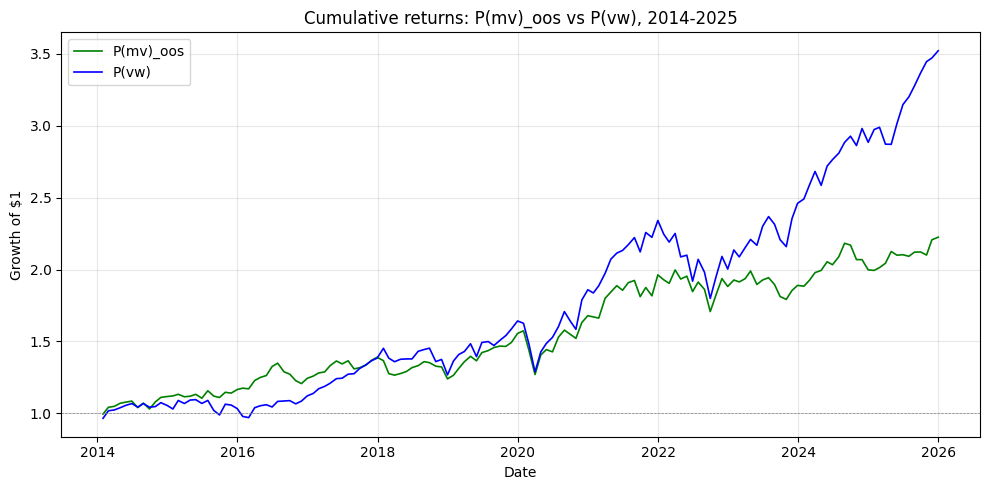

,ISIN,NAME,weight
1,US9311421039,WALMART,8.42%
2,US4278661081,HERSHEY,6.64%
3,CH0014786500,VALIANT 'R',6.57%
4,US3703341046,GENERAL MILLS,5.90%
5,US2091151041,CONSOLIDATED EDISON,5.50%
6,US74834L1008,QUEST DIAGNOSTICS,5.41%
7,US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,5.06%
8,US8425871071,SOUTHERN,4.47%
9,DK0060448595,COLOPLAST B,3.79%
10,US8725401090,TJX,3.64%


In [5]:
# Value-weighted benchmark P(vw).
# Universe: same yearly investable set as the MVP, so the comparison (and the
# WACI/CF comparison in Part II) is on a like-for-like basis.
# Spec timing: w_{i,t} = Cap_{i,t} / sum_j Cap_{j,t}, applied to R_{i,t+1}.

vw_rows = []
for year in range(START_YEAR, END_YEAR + 1):
    investment_year = year + 1
    investable_isins = investment_set.loc[
        (investment_set["screen_year"] == year) & investment_set["investable_for_next_year"],
        "ISIN"
    ].tolist()
    if not investable_isins:
        continue

    inv_cols  = get_investment_year_cols(ret_month_cols, investment_year)
    inv_dates = [pd.Timestamp(c) for c in inv_cols]

    for col, dt in zip(inv_cols, inv_dates):
        # Cap at end of the previous month (start of return month)
        prev_period = (dt - pd.DateOffset(months=1)).to_period("M")
        prev_match  = [c for c in mv_month_cols if pd.Timestamp(c).to_period("M") == prev_period]
        if not prev_match:
            continue
        prev_col = prev_match[0]

        caps = mv_by_isin.reindex(investable_isins)[prev_col].apply(pd.to_numeric, errors="coerce")
        rets = ri_ret_by_isin.reindex(investable_isins)[col].apply(pd.to_numeric, errors="coerce")
        valid = caps.notna() & rets.notna()
        if not valid.any():
            continue
        w  = caps[valid] / caps[valid].sum()
        rp = float((w * rets[valid]).sum())
        vw_rows.append({"date": dt, "Rp_vw": rp})

vw_monthly_returns = pd.DataFrame(vw_rows).sort_values("date").reset_index(drop=True)
vw_monthly_returns.to_csv(OUT_DIR / VW_RET_FILE, index=False)

# Merge MVP and VW returns
compare_df = (mvp_monthly_returns.merge(vw_monthly_returns, on="date", how="inner")
              .sort_values("date").set_index("date"))
compare_df["cum_mvp"] = (1.0 + compare_df["Rp_mvp"]).cumprod()
compare_df["cum_vw"]  = (1.0 + compare_df["Rp_vw"]).cumprod()

# Side-by-side performance table
mvp_stats = summary_stats(compare_df["Rp_mvp"], "P(mv)_oos", rf_monthly=rf_monthly_avg)
vw_stats  = summary_stats(compare_df["Rp_vw"],  "P(vw)",     rf_monthly=rf_monthly_avg)
perf = pd.DataFrame([mvp_stats, vw_stats])[
    ["portfolio", "n_months", "ann_mean_return", "ann_volatility",
     "sharpe_ratio", "min_monthly_return", "max_monthly_return"]
].rename(columns={
    "portfolio": "Portfolio", "n_months": "T",
    "ann_mean_return": "Ann. Mean", "ann_volatility": "Ann. Vol",
    "sharpe_ratio": "Sharpe", "min_monthly_return": "Min", "max_monthly_return": "Max",
})
display_perf = perf.copy()
for c in ["Ann. Mean", "Ann. Vol", "Min", "Max"]:
    display_perf[c] = display_perf[c].map(lambda x: f"{x:.2%}")
display_perf["Sharpe"] = display_perf["Sharpe"].map(lambda x: f"{x:.3f}")

from IPython.display import display
display(display_perf)
perf.to_csv(OUT_DIR / "mvp_vs_vw_performance_summary.csv", index=False)
compare_df.to_csv(OUT_DIR / "mvp_vs_vw_monthly_comparison.csv")

# Cumulative-return plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(compare_df.index, compare_df["cum_mvp"], label="P(mv)_oos", linewidth=1.2, color="green")
ax.plot(compare_df.index, compare_df["cum_vw"],  label="P(vw)",     linewidth=1.2, color="blue")
ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.5)
ax.set_xlabel("Date"); ax.set_ylabel("Growth of $1")
ax.set_title("Cumulative returns: P(mv)_oos vs P(vw), 2014-2025")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "cumulative_returns_plot.png", dpi=300, bbox_inches="tight")
plt.show()

# Top-10 holdings of the first MVP rebalance (Dec-2013 weights, held over 2014).
top10 = (weights_by_year[weights_by_year["screen_year"] == START_YEAR]
         .nlargest(10, "weight")[["ISIN", "weight"]]
         .reset_index(drop=True))
top10.insert(1, "NAME", top10["ISIN"].map(isin_to_name))
top10.index = range(1, len(top10) + 1)
top10["weight"] = top10["weight"].map(lambda x: f"{x:.2%}")

from IPython.display import display
display(top10)

## Excel Export

In [6]:
mvp_returns = compare_df["Rp_mvp"]
vw_returns  = compare_df["Rp_vw"]

# 1. Summary statistics

mvp_stats = summary_stats(mvp_returns, "MVP", rf_monthly=rf_monthly_avg)
vw_stats  = summary_stats(vw_returns,  "VW",  rf_monthly=rf_monthly_avg)

# Add cumulative return and annualised cumulative return (CAGR)
n_months = len(mvp_returns)
mvp_cum = (1 + mvp_returns).prod() - 1
vw_cum  = (1 + vw_returns).prod() - 1

mvp_stats["cumulative_return"]            = mvp_cum
vw_stats["cumulative_return"]             = vw_cum
mvp_stats["ann_cumulative_return"]        = (1 + mvp_cum) ** (12 / n_months) - 1
vw_stats["ann_cumulative_return"]         = (1 + vw_cum)  ** (12 / n_months) - 1

stats_df = pd.DataFrame([vw_stats, mvp_stats])

# 2. Monthly returns for the template

returns_df = pd.DataFrame({
    "VW": vw_returns,
    "MVP": mvp_returns
})

returns_df.index.name = "Date"

# 3. Export to Excel

stats_df.to_excel(OUT_DIR / "summary_stats.xlsx", index=False)
returns_df.to_excel(OUT_DIR / "monthly_returns.xlsx")

print("\nExcel files exported successfully.")
print(f"Saved in: {OUT_DIR}")


Excel files exported successfully.
Saved in: /Users/saarj/Documents/The Drive/UNIL Masters/Year 1/Spring Semester/Sustainability Aware Asset Management/AS- Sustainability Aware Asset Management Project /results


## 2.4 Robustness Check — Covariance Estimator

The project specifies the biased MLE sample covariance $\hat{\Sigma}_Y = \frac{1}{\tau}\sum(R_{t-k}-\hat{\mu})(R_{t-k}-\hat{\mu})'$.
With $N \approx 800$–$1{,}100$ firms and $\tau = 120$ monthly observations the matrix
is rank-deficient (rank $\leq \tau$), leaving $\sim N - \tau$ zero eigenvalues. For the MVP
this inflates concentration but still yields a solution. For the **tracking-error** problems
in §3.3 and §4.1 the null space allows the solver to move weights arbitrarily far from
the benchmark at zero TE cost, collapsing the carbon-constrained portfolio to a degenerate
corner solution.

We compare three estimators (all selectable via `COV_METHOD`):

| Estimator | Structure | Full-rank? | Bias |
|---|---|---|---|
| `sample` | $\frac{1}{\tau}R^\top R$ | ❌ when $N>\tau$ | Unbiased |
| `single_factor` | $\beta\beta'\sigma_m^2 + D$ | ✅ by construction | Economic (CAPM) |
| `ledoit_wolf` | $\delta F + (1-\delta)S$ | ✅ always | Statistical |

**We use Ledoit-Wolf as our primary estimator** (i.e. `COV_METHOD = "ledoit_wolf"`) for three reasons:
(i) it is full-rank and positive definite for any $N$ and $\tau$, eliminating degenerate solutions;
(ii) the shrinkage intensity $\delta$ is estimated analytically from the data with no free parameters;
(iii) Chan, Karceski and Lakonishok (1999) show shrinkage estimators deliver better out-of-sample
Sharpe ratios than the sample covariance (0.67 vs 0.64 in their study).
The single-factor model is also full-rank but imposes CAPM structure that may be too restrictive
for a cross-regional AMER+EUR universe with industry heterogeneity.


§2.4 Robustness check: running MVP under 3 covariance estimators...
Primary estimator for all sections: Ledoit-Wolf (already active via COV_METHOD)

Robustness check — MVP under three covariance estimators
  2013: done
  2014: done
  2015: done
  2016: done
  2017: done
  2018: done
  2019: done
  2020: done
  2021: done
  2022: done
  2023: done
  2024: done

Table: MVP performance under three covariance estimators
Period: Jan 2014 — Dec 2025  (144 months)
                     Ann. Return Ann. Vol. Sharpe Min Monthly Max Monthly
portfolio                                                                
Sample covariance          6.67%    11.84%  0.416     -12.47%      11.10%
Single-factor (CAPM)       8.78%    12.48%  0.563     -11.09%      11.42%
Ledoit-Wolf ✓              7.35%    11.58%  0.484     -11.77%      10.74%
Value-weighted            11.54%    14.19%  0.690     -13.13%      12.88%

Firms in investment set (sample year 2013 vs 2024):
  sample              : 771 (2013)  1120 

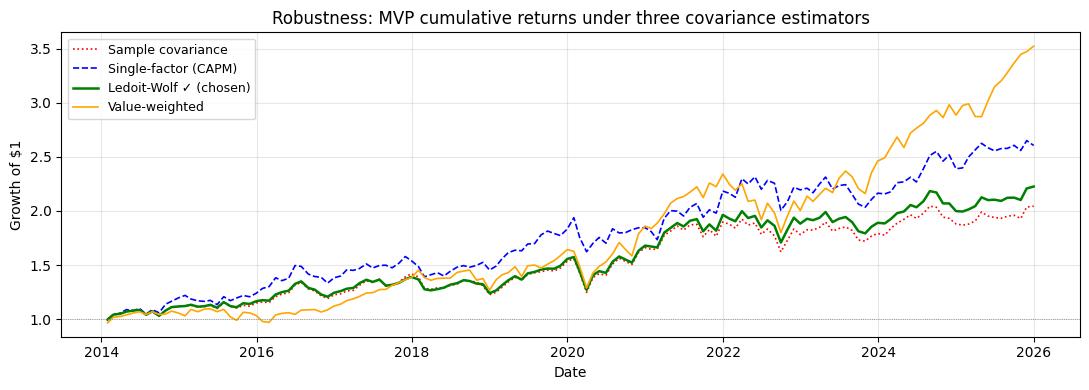


Realised variance — full sample:
                     Ann. Variance Ann. Vol.
Estimator                                   
Sample covariance           0.0140    11.84%
Single-factor (CAPM)        0.0156    12.48%
Ledoit-Wolf (chosen)        0.0134    11.58%
Value-weighted              0.0201    14.19%


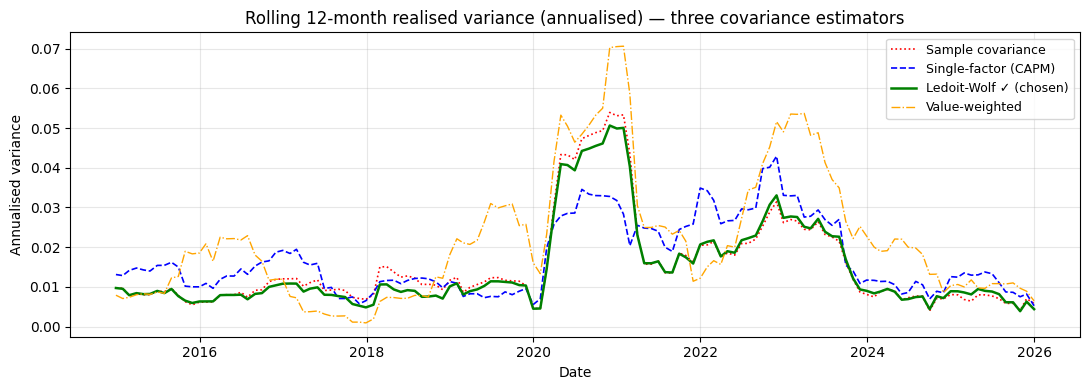


All subsequent sections use COV_METHOD = 'ledoit_wolf' (set in Cell 0).


In [7]:
# §2.4 — Covariance estimator comparison.
# This cell runs the MVP under all three estimators (sample, single-factor, Ledoit-Wolf)
# and produces a performance table and cumulative return plot.
# COV_METHOD is already set to "ledoit_wolf" in Cell 0 so every section runs
# with Ledoit-Wolf automatically — this cell is purely a methodology justification.
# No manual intervention is needed: run all cells top to bottom.
print("§2.4 Robustness check: running MVP under 3 covariance estimators...")
print("Primary estimator for all sections: Ledoit-Wolf (already active via COV_METHOD)")
print()

rob_rows = {m: [] for m in ["sample", "single_factor", "ledoit_wolf"]}
n_firms  = {}

print("Robustness check — MVP under three covariance estimators")
print("=" * 65)

for year in range(START_YEAR, END_YEAR + 1):
    investment_year = year + 1

    investable_isins = investment_set.loc[
        (investment_set["screen_year"] == year) & investment_set["investable_for_next_year"],
        "ISIN"
    ].tolist()
    if not investable_isins:
        continue

    window_cols = get_trailing_window_cols(ret_month_cols, end_year=year,
                                           window_years=WINDOW_YEARS)
    if not window_cols:
        continue

    inv_cols = get_investment_year_cols(ret_month_cols, investment_year)
    if not inv_cols:
        continue

    # Market-cap vector for single-factor VW proxy
    dec_col = get_december_col(mv_month_cols, year)
    mv_vec  = (mv_by_isin.reindex(investable_isins)[dec_col]
               .apply(pd.to_numeric, errors="coerce")
               if dec_col else None)
    mv_series = mv_vec

    for method in ["sample", "single_factor", "ledoit_wolf"]:
        mu_r, cov_r, vis = estimate_moments(
            ri_ret_by_isin, investable_isins, window_cols,
            cov_method=method,
            mv_series=mv_series,
        )
        if not vis:
            continue
        try:
            w_r = solve_mvp(cov_r)
        except RuntimeError:
            continue

        n_firms.setdefault(method, {})[year] = len(vis)

        current_w = pd.Series(w_r, index=vis)
        for col in inv_cols:
            rets = ri_ret_by_isin.reindex(vis)[col].apply(pd.to_numeric, errors="coerce")
            mask = rets.notna()
            wm   = current_w[mask]
            rm   = rets[mask]
            rp   = float((wm / wm.sum() * rm).sum()) if wm.sum() > 1e-8 else 0.0
            rob_rows[method].append({"date": pd.Timestamp(col), "Rp": rp})
            new_w = current_w.copy()
            new_w[mask] = current_w[mask] * (1.0 + rets[mask])
            if new_w.sum() > 1e-8:
                current_w = new_w / new_w.sum()

    print(f"  {year}: done")

# ── Align and compute stats ────────────────────────────────────────────────────
def _to_series(rows):
    return (pd.DataFrame(rows)
            .assign(date=lambda x: pd.to_datetime(x["date"]))
            .sort_values("date").set_index("date")["Rp"])

ret_sc  = _to_series(rob_rows["sample"])
ret_sf  = _to_series(rob_rows["single_factor"])
ret_lw  = _to_series(rob_rows["ledoit_wolf"])
ret_vw  = compare_df["Rp_vw"]

common = ret_sc.index.intersection(ret_sf.index).intersection(ret_lw.index).intersection(ret_vw.index)
ret_sc, ret_sf, ret_lw, ret_vw = (s.loc[common] for s in [ret_sc, ret_sf, ret_lw, ret_vw])

stats_rob = pd.DataFrame([
    summary_stats(ret_sc, "Sample covariance",    rf_monthly=rf_monthly_avg),
    summary_stats(ret_sf, "Single-factor (CAPM)", rf_monthly=rf_monthly_avg),
    summary_stats(ret_lw, "Ledoit-Wolf ✓",        rf_monthly=rf_monthly_avg),
    summary_stats(ret_vw, "Value-weighted",        rf_monthly=rf_monthly_avg),
]).set_index("portfolio")

disp = stats_rob[["ann_mean_return","ann_volatility","sharpe_ratio",
                   "min_monthly_return","max_monthly_return"]].copy()
disp.columns = ["Ann. Return","Ann. Vol.","Sharpe","Min Monthly","Max Monthly"]
for c in ["Ann. Return","Ann. Vol.","Min Monthly","Max Monthly"]:
    disp[c] = disp[c].apply(lambda x: f"{x:.2%}")
disp["Sharpe"] = disp["Sharpe"].apply(lambda x: f"{x:.3f}")

print(f"\n{'='*65}")
print("Table: MVP performance under three covariance estimators")
print(f"Period: {common.min().strftime('%b %Y')} — {common.max().strftime('%b %Y')}"
      f"  ({len(common)} months)")
print(f"{'='*65}")
print(disp.to_string())
print(f"{'='*65}")
stats_rob.to_csv(OUT_DIR / "robustness_covariance_comparison.csv")

# ── Universe size: LW/sample need full 120-month history; SF only needs 36 ─────
print("\nFirms in investment set (sample year 2013 vs 2024):")
for method in ["sample", "single_factor", "ledoit_wolf"]:
    n13 = n_firms.get(method, {}).get(START_YEAR, "—")
    n24 = n_firms.get(method, {}).get(END_YEAR, "—")
    print(f"  {method:<20}: {n13} (2013)  {n24} (2024)")

# ── Cumulative return plot ────────────────────────────────────────────────────
cum_sc = (1 + ret_sc).cumprod()
cum_sf = (1 + ret_sf).cumprod()
cum_lw = (1 + ret_lw).cumprod()
cum_vw = (1 + ret_vw).cumprod()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(cum_sc.index, cum_sc.values, "r:",    linewidth=1.2, label="Sample covariance")
ax.plot(cum_sf.index, cum_sf.values, "b--",   linewidth=1.2, label="Single-factor (CAPM)")
ax.plot(cum_lw.index, cum_lw.values, "green", linewidth=1.8, label="Ledoit-Wolf ✓ (chosen)")
ax.plot(cum_vw.index, cum_vw.values, color="orange", linewidth=1.2, label="Value-weighted")
ax.axhline(1.0, color="grey", linestyle=":", linewidth=0.6)
ax.set_title("Robustness: MVP cumulative returns under three covariance estimators")
ax.set_ylabel("Growth of $1"); ax.set_xlabel("Date")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / "robustness_covariance_cumulative.png", dpi=300, bbox_inches="tight")
plt.show()


# ── Realised variance comparison ──────────────────────────────────────────────
# The MVP objective is to minimise variance, not maximise return.
# We compute the rolling 12-month realised variance for each estimator
# so the comparison is on the metric the optimizer was actually targeting.

window = 12   # rolling window in months

rv_sc  = ret_sc.rolling(window).var() * 12    # annualised
rv_sf  = ret_sf.rolling(window).var() * 12
rv_lw  = ret_lw.rolling(window).var() * 12
rv_vw  = ret_vw.rolling(window).var() * 12

# Full-sample annualised variance (single number per method)
var_summary = pd.DataFrame({
    "Estimator":   ["Sample covariance", "Single-factor (CAPM)",
                    "Ledoit-Wolf (chosen)", "Value-weighted"],
    "Ann. Variance": [ret_sc.var()*12, ret_sf.var()*12,
                      ret_lw.var()*12, ret_vw.var()*12],
    "Ann. Vol.":     [ret_sc.std()*12**0.5, ret_sf.std()*12**0.5,
                      ret_lw.std()*12**0.5, ret_vw.std()*12**0.5],
}).set_index("Estimator")

var_summary["Ann. Variance"] = var_summary["Ann. Variance"].map(lambda x: f"{x:.4f}")
var_summary["Ann. Vol."]     = var_summary["Ann. Vol."].map(lambda x: f"{x:.2%}")

print("\nRealised variance — full sample:")
print(var_summary.to_string())

# Rolling variance plot
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(rv_sc.index,  rv_sc.values,  "r:",    linewidth=1.2, label="Sample covariance")
ax.plot(rv_sf.index,  rv_sf.values,  "b--",   linewidth=1.2, label="Single-factor (CAPM)")
ax.plot(rv_lw.index,  rv_lw.values,  "green", linewidth=1.8, label="Ledoit-Wolf ✓ (chosen)")
ax.plot(rv_vw.index,  rv_vw.values,  color="orange", linewidth=1.0,
        linestyle="-.", label="Value-weighted")
ax.set_title(f"Rolling {window}-month realised variance (annualised) — three covariance estimators")
ax.set_ylabel("Annualised variance")
ax.set_xlabel("Date")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / "robustness_rolling_variance.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nAll subsequent sections use COV_METHOD =", repr(COV_METHOD), "(set in Cell 0).")


# Part II - Portfolio Allocation with Carbon Emission Reduction
## 3 Allocation with a 50% Reduction in Carbon Emissions
Only Scope 1 emissions (direct emissions from company-owned sources) are used; Scope 2 is excluded.
## 3.1 Carbon Emissions Metrics

We quantify portfolio carbon exposure through two metrics for each screen year $Y$:

**WACI** (Scope 1 intensity relative to revenue):
$\;WACI^{(p)}_Y = \sum_i \alpha_{i,Y}\, E_{i,Y} / \mathrm{Rev}_{i,Y}$

**CF** (carbon footprint relative to market cap):
$\;CF^{(p)}_Y = \sum_i (\alpha_{i,Y} / Cap_{i,Y})\, E_{i,Y}$

Both are reported for P(mv)\_oos and P(vw)\_oos as baselines for Sections 3.2–4.2.

,Year,WACI_MVP,WACI_VW,CF_MVP,CF_VW,WACI_MVP_vs_VW_%,CF_MVP_vs_VW_%
0,2013,737.7,176.3,359.4,149.1,318.5,141.0
1,2014,606.4,182.8,254.0,145.6,231.7,74.4
2,2015,449.8,166.2,215.8,148.5,170.6,45.3
3,2016,330.3,195.1,129.0,134.1,69.3,-3.7
4,2017,362.1,184.6,159.7,107.8,96.2,48.1
5,2018,529.2,168.4,271.2,115.5,214.3,134.9
6,2019,339.3,147.8,137.1,84.0,129.5,63.2
7,2020,409.7,121.5,183.0,67.8,237.2,169.8
8,2021,270.0,125.7,91.4,55.9,114.9,63.4
9,2022,200.8,121.3,78.7,65.5,65.6,20.2



Top-10 contributors to portfolio WACI in 2024:

--- MVP ---


,name,ISIN,weight,CI,contribution
1,CMS ENERGY,US1258961002,1.89%,"2,155",40.8
2,FIRSTENERGY,US3379321074,3.16%,"1,089",34.5
3,XCEL ENERGY,US98389B1008,1.46%,"2,299",33.5
4,COTERRA ENERGY,US1270971039,3.66%,207,7.6
5,EVERGY,US30034W1062,0.09%,"4,254",3.7
6,EBRO FOODS,ES0112501012,5.47%,58,3.2
7,HORMEL FOODS,US4404521001,4.54%,52,2.3
8,RHOEN-KLINIKUM,DE0007042301,7.98%,17,1.4
9,SAPUTO,CA8029121057,3.32%,40,1.3
10,CAMELLIA,GB0001667087,0.25%,426,1.1



--- VW ---


,name,ISIN,weight,CI,contribution
1,SOUTHERN,US8425871071,0.17%,"3,138",5.3
2,NEXTERA ENERGY,US65339F1012,0.27%,"1,504",4.1
3,DUKE ENERGY,US26441C2044,0.16%,"2,513",3.9
4,EXXON MOBIL,US30231G1022,0.87%,272,2.4
5,HOLCIM,CH0012214059,0.10%,"2,275",2.4
6,AMER.ELEC.PWR.,US0255371017,0.09%,"2,471",2.3
7,ENTERGY,US29364G1031,0.06%,"3,555",2.1
8,DOMINION ENERGY,US25746U1097,0.08%,"2,051",1.7
9,TC ENERGY,CA87807B1076,0.09%,"1,887",1.7
10,XCEL ENERGY,US98389B1008,0.07%,"2,299",1.7


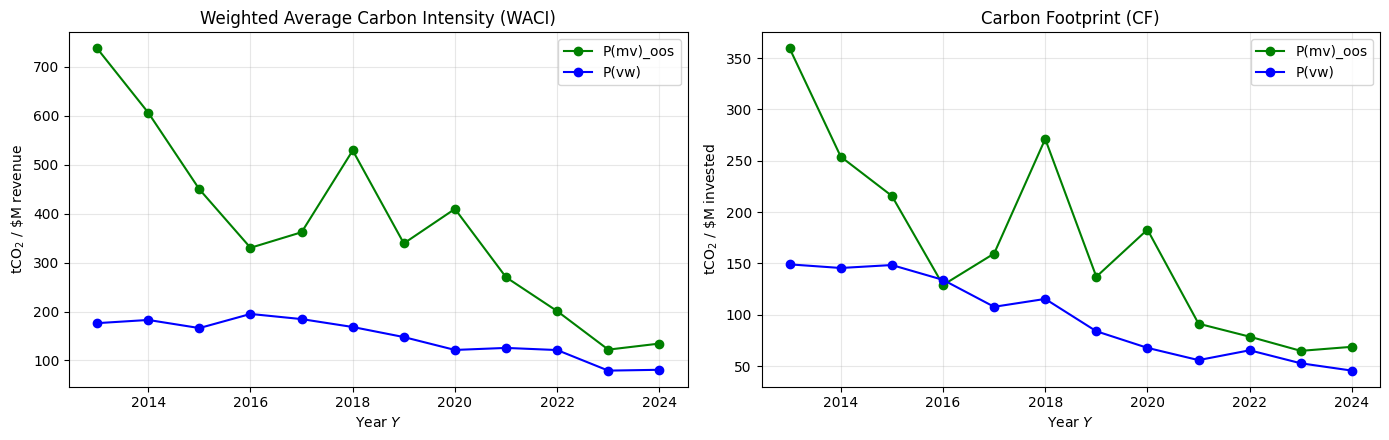

In [8]:
# §3.1 — carbon intensity, WACI, and carbon footprint for the MVP and the VW.
# Universe: same yearly investable set as §2.

# (a) Carbon intensity per firm-year, vectorized.
# CI_{i,Y} = E_{i,Y} / (Rev_{i,Y}/1000), undefined when Rev <= 0.
ci_table = co2_by_isin[year_cols].copy()
for y in year_cols:
    rev_y = rev_by_isin[y]
    ok    = rev_y > 0
    ci_table[y] = co2_by_isin[y].where(ok) / (rev_y.where(ok) / 1000.0)

# (b) WACI and CF, year by year, for both portfolios.
results = []
contrib_rows = []  # for top-10 driver tables

for year in range(START_YEAR, END_YEAR + 1):
    if year not in ci_table.columns:
        continue

    yec = get_december_col(mv_month_cols, year)
    if yec is None:
        continue
    cap_y = mv_by_isin[yec]
    ci_y  = ci_table[year]
    co2_y = co2_by_isin[year]

    # ---- MVP ----
    w_mvp = weights_by_year.loc[weights_by_year["screen_year"] == year].set_index("ISIN")["weight"]
    if w_mvp.empty:
        waci_mvp = cf_mvp = np.nan
    else:
        ci_aligned  = ci_y.reindex(w_mvp.index)
        co2_aligned = co2_y.reindex(w_mvp.index)
        cap_aligned = cap_y.reindex(w_mvp.index)
        waci_mvp = float((w_mvp * ci_aligned).sum(skipna=True))
        cf_mvp   = float((w_mvp * (co2_aligned / cap_aligned)).sum(skipna=True))

        contrib = (w_mvp * ci_aligned).dropna().sort_values(ascending=False).head(10)
        for isin, val in contrib.items():
            contrib_rows.append({"year": year, "portfolio": "MVP",
                                 "ISIN": isin, "name": isin_to_name.get(isin, ""),
                                 "weight": float(w_mvp[isin]),
                                 "CI": float(ci_aligned[isin]),
                                 "contribution": float(val)})

    # ---- VW (over the same investable set) ----
    investable_isins = investment_set.loc[
        (investment_set["screen_year"] == year) & investment_set["investable_for_next_year"],
        "ISIN"
    ].tolist()
    cap_inv = cap_y.reindex(investable_isins).dropna()
    if cap_inv.empty:
        waci_vw = cf_vw = np.nan
    else:
        w_vw        = cap_inv / cap_inv.sum()
        ci_aligned  = ci_y.reindex(w_vw.index)
        co2_aligned = co2_y.reindex(w_vw.index)
        waci_vw = float((w_vw * ci_aligned).sum(skipna=True))
        cf_vw   = float(co2_aligned.sum(skipna=True) / cap_inv.sum())  # spec: (1/Cap_Y) sum E_i

        contrib = (w_vw * ci_aligned).dropna().sort_values(ascending=False).head(10)
        for isin, val in contrib.items():
            contrib_rows.append({"year": year, "portfolio": "VW",
                                 "ISIN": isin, "name": isin_to_name.get(isin, ""),
                                 "weight": float(w_vw[isin]),
                                 "CI": float(ci_aligned[isin]),
                                 "contribution": float(val)})

    results.append({"Year": year,
                    "WACI_MVP": waci_mvp, "WACI_VW": waci_vw,
                    "CF_MVP":   cf_mvp,   "CF_VW":   cf_vw})

carbon_summary = pd.DataFrame(results).sort_values("Year").reset_index(drop=True)
# Negative values mean MVP is dirtier than the benchmark — exactly the case here.
carbon_summary["WACI_MVP_vs_VW_%"] = (carbon_summary["WACI_MVP"] / carbon_summary["WACI_VW"] - 1) * 100
carbon_summary["CF_MVP_vs_VW_%"]   = (carbon_summary["CF_MVP"]   / carbon_summary["CF_VW"]   - 1) * 100
carbon_summary.to_csv(OUT_DIR / "carbon_summary.csv", index=False)

contrib_df = pd.DataFrame(contrib_rows)
contrib_df.to_csv(OUT_DIR / "carbon_top10_contributors.csv", index=False)

from IPython.display import display
display(carbon_summary.round(1))

# (c) Top-10 contributors to portfolio WACI in the latest year.
latest = carbon_summary["Year"].max()
print(f"\nTop-10 contributors to portfolio WACI in {latest}:")
for label in ["MVP", "VW"]:
    print(f"\n--- {label} ---")
    sub = (contrib_df[(contrib_df["year"] == latest) & (contrib_df["portfolio"] == label)]
           .sort_values("contribution", ascending=False).head(10).reset_index(drop=True))
    sub.index = range(1, len(sub) + 1)
    sub["weight"]       = sub["weight"].map(lambda x: f"{x:.2%}")
    sub["CI"]           = sub["CI"].map(lambda x: f"{x:,.0f}")
    sub["contribution"] = sub["contribution"].map(lambda x: f"{x:,.1f}")
    display(sub[["name", "ISIN", "weight", "CI", "contribution"]])

# (d) Plot.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
ax1.plot(carbon_summary["Year"], carbon_summary["WACI_MVP"], "-o", label="P(mv)_oos", color="green")
ax1.plot(carbon_summary["Year"], carbon_summary["WACI_VW"],  "-o", label="P(vw)",     color="blue")
ax1.set_title("Weighted Average Carbon Intensity (WACI)")
ax1.set_ylabel(r"tCO$_2$ / \$M revenue"); ax1.set_xlabel("Year $Y$")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(carbon_summary["Year"], carbon_summary["CF_MVP"], "-o", label="P(mv)_oos", color="green")
ax2.plot(carbon_summary["Year"], carbon_summary["CF_VW"],  "-o", label="P(vw)",     color="blue")
ax2.set_title("Carbon Footprint (CF)")
ax2.set_ylabel(r"tCO$_2$ / \$M invested"); ax2.set_xlabel("Year $Y$")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(OUT_DIR / "carbon_metrics_plot.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.2 Carbon-Constrained MVP — P(mv)\_oos(0.5)

We extend the MVP with a carbon footprint constraint: the portfolio CF must not exceed 50 % of the unconstrained MVP CF.

The carbon footprint is $CF^{(p)}_Y = \sum_i (\alpha_{i,Y} / Cap_{i,Y}) \cdot E_{i,Y}$, giving a linear constraint:

$$\min_{\alpha_Y}\; \alpha_Y^\top \hat{\Sigma}_Y \alpha_Y \quad\text{s.t.}\quad \sum_i \frac{E_{i,Y}}{Cap_{i,Y}}\,\alpha_{i,Y} \leq 0.5 \times CF^{(mv)}_Y,\; \alpha_Y^\top e = 1,\; \alpha_{i,Y} \geq 0$$

Out-of-sample returns follow the same weight-drift procedure as Section 2.2.

,Portfolio,T,Ann. Mean,Ann. Vol,Sharpe,Min,Max
0,P(mv)_oos,144,7.35%,11.58%,0.484,-11.77%,10.74%
1,P(mv)_oos(0.5),144,7.32%,11.52%,0.483,-11.27%,10.87%


,Year,WACI_MVP,WACI_MVP05,CF_MVP,CF_MVP05,WACI_change_%,CF_change_%
0,2013,737.71,345.12,359.39,179.70,-53.22,-50.0
1,2014,606.38,286.74,253.97,126.98,-52.71,-50.0
2,2015,449.78,204.99,215.79,107.89,-54.42,-50.0
3,2016,330.29,148.07,129.03,64.52,-55.17,-50.0
4,2017,362.09,175.11,159.66,79.83,-51.64,-50.0
5,2018,529.25,245.17,271.21,135.61,-53.68,-50.0
6,2019,339.26,153.43,137.08,68.54,-54.78,-50.0
7,2020,409.73,196.71,182.99,91.49,-51.99,-50.0
8,2021,269.99,156.84,91.36,45.68,-41.91,-50.0
9,2022,200.83,84.43,78.72,39.36,-57.96,-50.0


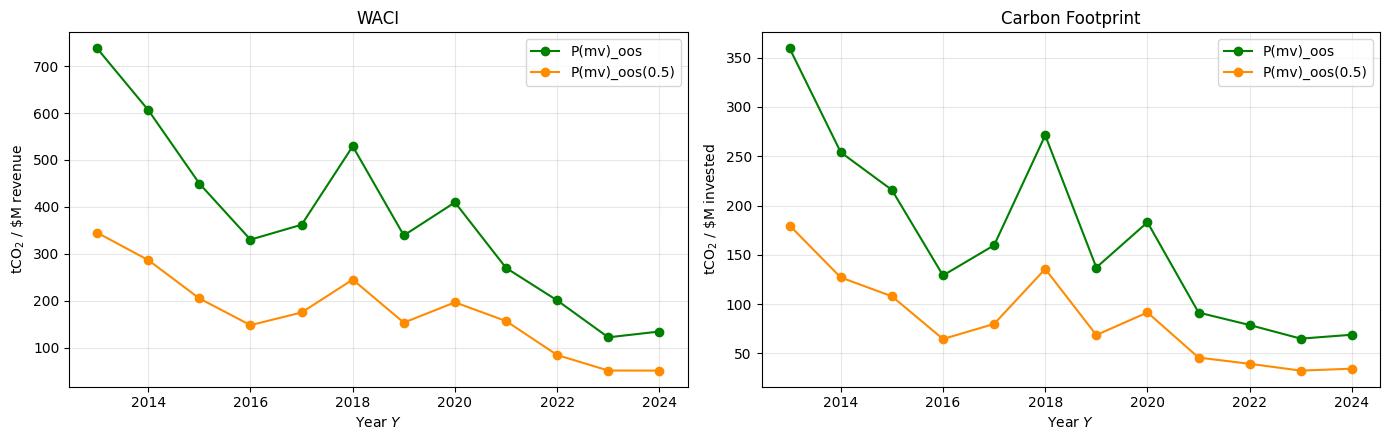

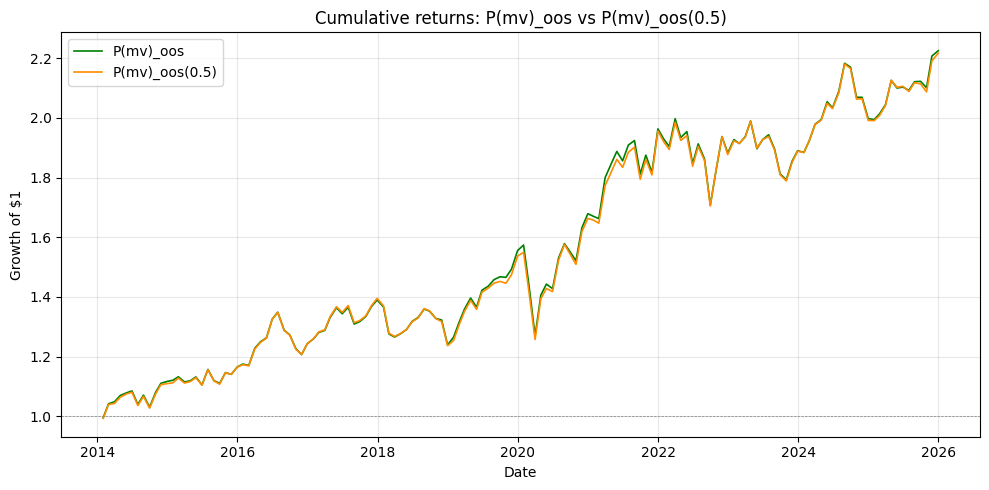


Top-10 most under-weighted firms (MVP -> MVP(0.5)):


,NAME,Country,w_mvp_avg,w_mvp05_avg,weight_change,CI_avg
1,SOUTHERN,US,2.62%,0.98%,-1.65%,"4,921"
2,DUKE ENERGY,US,0.82%,0.11%,-0.71%,"5,127"
3,CMS ENERGY,US,0.89%,0.20%,-0.69%,"3,175"
4,FIRSTENERGY,US,1.99%,1.47%,-0.52%,"2,187"
5,WEC ENERGY GROUP,US,0.66%,0.17%,-0.49%,"4,418"
6,HAWAIIAN ELECTRIC INDS.,US,0.73%,0.38%,-0.35%,"1,553"
7,PPL,US,0.44%,0.25%,-0.19%,"4,087"
8,NISOURCE,US,0.23%,0.04%,-0.19%,"2,422"
9,XCEL ENERGY,US,0.18%,0.00%,-0.18%,"4,213"
10,DOMINION ENERGY,US,0.42%,0.25%,-0.17%,"2,877"



Top-10 most over-weighted firms (MVP -> MVP(0.5)):


,NAME,Country,w_mvp_avg,w_mvp05_avg,weight_change,CI_avg
1,CONSOLIDATED EDISON,US,2.97%,4.06%,1.09%,258
2,PUBLIC STORAGE,US,0.20%,0.64%,0.44%,6
3,CAL.WATER SER.,US,0.57%,0.88%,0.31%,8
4,WALMART,US,4.00%,4.28%,0.29%,14
5,ESSENTIAL UTILITIES,US,1.30%,1.57%,0.28%,165
6,PG&E,US,1.39%,1.67%,0.28%,229
7,HERSHEY,US,4.32%,4.56%,0.24%,19
8,DIGNITY DEAD - DELIST.25/05/23,GB,1.53%,1.76%,0.23%,40
9,FTI CONSULTING,US,4.17%,4.38%,0.21%,0
10,PROCTER & GAMBLE,US,0.48%,0.67%,0.19%,31



Avg CI of 10 most under-weighted: 3,498  tCO2/$M revenue
Avg CI of 10 most over-weighted : 77  tCO2/$M revenue


In [9]:
# §3.2 — long-only minimum variance with CF <= 0.5 * CF of P(mv)_oos.
# Same QP as §2.2 plus a linear carbon-footprint constraint.

CF_REDUCTION = 0.50

# Pull the unconstrained MVP carbon footprint per year from §3.1's table
mvp_cf_by_year = dict(zip(carbon_summary["Year"], carbon_summary["CF_MVP"]))

def solve_cf_constrained_mvp(cov, cf_coef, cf_limit):
    n = cov.shape[0]
    w = cp.Variable(n)
    prob = cp.Problem(
        cp.Minimize(cp.quad_form(w, cp.psd_wrap(cov))),
        [cp.sum(w) == 1, w >= 0, cf_coef @ w <= cf_limit],
    )
    prob.solve(solver=cp.OSQP, verbose=False, eps_abs=1e-8, eps_rel=1e-8, max_iter=50_000)
    if prob.status not in ["optimal", "optimal_inaccurate"]:
        raise RuntimeError(f"CF-constrained MVP failed: {prob.status}")
    weights = np.clip(np.array(w.value).flatten(), 0, None)
    return weights / weights.sum()

mvp05_weights_rows = []
mvp05_return_rows  = []
mvp05_summary_rows = []

for year in range(START_YEAR, END_YEAR + 1):
    investment_year = year + 1

    investable_isins = investment_set.loc[
        (investment_set["screen_year"] == year) & investment_set["investable_for_next_year"],
        "ISIN"].tolist()
    if not investable_isins:
        continue

    window_cols = get_trailing_window_cols(ret_month_cols, end_year=year, window_years=WINDOW_YEARS)
    yec = get_december_col(mv_month_cols, year)
    if yec is None:
        continue

    mu, cov, valid_isins = estimate_moments(ri_ret_by_isin, investable_isins, window_cols)
    if not valid_isins:
        continue

    cap_y = mv_by_isin[yec].reindex(valid_isins)
    co2_y = co2_by_isin[year].reindex(valid_isins) if year in co2_by_isin.columns else pd.Series(np.nan, index=valid_isins)
    cf_coef = (co2_y / cap_y).values
    if not np.all(np.isfinite(cf_coef)):
        n_bad = int(np.sum(~np.isfinite(cf_coef)))
        raise RuntimeError(f"{year}: {n_bad} valid_isins missing CO2 or Cap.")

    cf_target = mvp_cf_by_year.get(year)
    if cf_target is None or cf_target <= 0:
        continue
    cf_limit = (1.0 - CF_REDUCTION) * cf_target

    w_05 = solve_cf_constrained_mvp(cov, cf_coef, cf_limit)
    realized_cf = float(cf_coef @ w_05)

    for isin, w in zip(valid_isins, w_05):
        mvp05_weights_rows.append({"screen_year": year, "investment_year": investment_year,
                                   "ISIN": isin, "weight": w})

    mvp05_summary_rows.append({"screen_year": year, "investment_year": investment_year,
                               "n_assets": len(valid_isins),
                               "cf_target_unconstrained": cf_target,
                               "cf_limit": cf_limit, "cf_realized": realized_cf,
                               "binding": bool(np.isclose(realized_cf, cf_limit, atol=1e-6)),
                               "max_weight": float(w_05.max())})

    inv_cols  = get_investment_year_cols(ret_month_cols, investment_year)
    if not inv_cols:
        continue
    inv_dates = [pd.Timestamp(c) for c in inv_cols]
    current_w = pd.Series(w_05, index=valid_isins)

    for col, dt in zip(inv_cols, inv_dates):
        month_rets = ri_ret_by_isin.reindex(valid_isins)[col].apply(pd.to_numeric, errors="coerce")
        valid_mask = month_rets.notna()
        if not valid_mask.any() or current_w[valid_mask].sum() <= 1e-12:
            rp = 0.0
        else:
            w_active = current_w[valid_mask] / current_w[valid_mask].sum()
            rp       = float((w_active * month_rets[valid_mask]).sum())
            grown    = current_w[valid_mask] * (1.0 + month_rets[valid_mask])
            current_w = current_w.copy() * 0.0
            current_w[valid_mask] = grown / grown.sum()
        mvp05_return_rows.append({"date": dt, "Rp_mvp05": rp})

mvp05_weights_by_year = pd.DataFrame(mvp05_weights_rows)
mvp05_monthly_returns = pd.DataFrame(mvp05_return_rows).sort_values("date").reset_index(drop=True)
mvp05_summary_by_year = pd.DataFrame(mvp05_summary_rows)

mvp05_weights_by_year.to_csv(OUT_DIR / "mvp05_weights_by_year.csv", index=False)
mvp05_monthly_returns.to_csv(OUT_DIR / "mvp05_monthly_returns.csv", index=False)
mvp05_summary_by_year.to_csv(OUT_DIR / "mvp05_summary_by_year.csv", index=False)

# ---- Performance comparison vs P(mv)_oos ----
mvp_idx   = mvp_monthly_returns.set_index("date")["Rp_mvp"]
mvp05_idx = mvp05_monthly_returns.set_index("date")["Rp_mvp05"]
common_dates = mvp_idx.index.intersection(mvp05_idx.index)

stats_mvp   = summary_stats(mvp_idx.loc[common_dates],   "P(mv)_oos",      rf_monthly=rf_monthly_avg)
stats_mvp05 = summary_stats(mvp05_idx.loc[common_dates], "P(mv)_oos(0.5)", rf_monthly=rf_monthly_avg)

perf = pd.DataFrame([stats_mvp, stats_mvp05])[
    ["portfolio","n_months","ann_mean_return","ann_volatility","sharpe_ratio","min_monthly_return","max_monthly_return"]
].rename(columns={"portfolio":"Portfolio","n_months":"T",
                  "ann_mean_return":"Ann. Mean","ann_volatility":"Ann. Vol",
                  "sharpe_ratio":"Sharpe","min_monthly_return":"Min","max_monthly_return":"Max"})
display_perf = perf.copy()
for c in ["Ann. Mean","Ann. Vol","Min","Max"]:
    display_perf[c] = display_perf[c].map(lambda x: f"{x:.2%}")
display_perf["Sharpe"] = display_perf["Sharpe"].map(lambda x: f"{x:.3f}")

from IPython.display import display
display(display_perf)
perf.to_csv(OUT_DIR / "mvp_vs_mvp05_performance_summary.csv", index=False)

# ---- Carbon comparison ----
carbon_rows = []
for year in range(START_YEAR, END_YEAR + 1):
    yec = get_december_col(mv_month_cols, year)
    if yec is None or year not in co2_by_isin.columns: continue
    cap_y, co2_y, ci_y = mv_by_isin[yec], co2_by_isin[year], ci_table[year]

    def metrics(weights_df):
        w = weights_df.loc[weights_df["screen_year"] == year].set_index("ISIN")["weight"]
        if w.empty: return (np.nan, np.nan)
        ci_a, co2_a, cap_a = ci_y.reindex(w.index), co2_y.reindex(w.index), cap_y.reindex(w.index)
        return (float((w * ci_a).sum(skipna=True)),
                float((w * (co2_a / cap_a)).sum(skipna=True)))

    mvp_w, mvp_cf = metrics(weights_by_year)
    m05_w, m05_cf = metrics(mvp05_weights_by_year)
    carbon_rows.append({"Year": year, "WACI_MVP": mvp_w, "WACI_MVP05": m05_w,
                        "CF_MVP": mvp_cf, "CF_MVP05": m05_cf})

carbon_compare = pd.DataFrame(carbon_rows)
carbon_compare["WACI_change_%"] = (carbon_compare["WACI_MVP05"] / carbon_compare["WACI_MVP"] - 1) * 100
carbon_compare["CF_change_%"]   = (carbon_compare["CF_MVP05"]   / carbon_compare["CF_MVP"]   - 1) * 100
display(carbon_compare.round(2))
carbon_compare.to_csv(OUT_DIR / "mvp_vs_mvp05_carbon.csv", index=False)

# ---- Plots ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
ax1.plot(carbon_compare["Year"], carbon_compare["WACI_MVP"],   "-o", label="P(mv)_oos",      color="green")
ax1.plot(carbon_compare["Year"], carbon_compare["WACI_MVP05"], "-o", label="P(mv)_oos(0.5)", color="darkorange")
ax1.set_title("WACI"); ax1.set_ylabel(r"tCO$_2$ / \$M revenue"); ax1.set_xlabel("Year $Y$"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(carbon_compare["Year"], carbon_compare["CF_MVP"],   "-o", label="P(mv)_oos",      color="green")
ax2.plot(carbon_compare["Year"], carbon_compare["CF_MVP05"], "-o", label="P(mv)_oos(0.5)", color="darkorange")
ax2.set_title("Carbon Footprint"); ax2.set_ylabel(r"tCO$_2$ / \$M invested"); ax2.set_xlabel("Year $Y$"); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); fig.savefig(OUT_DIR / "mvp_vs_mvp05_carbon_plot.png", dpi=300, bbox_inches="tight"); plt.show()

mvp_cum   = (1.0 + mvp_idx.loc[common_dates]).cumprod()
mvp05_cum = (1.0 + mvp05_idx.loc[common_dates]).cumprod()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mvp_cum.index,   mvp_cum,   linewidth=1.2, label="P(mv)_oos",      color="green")
ax.plot(mvp05_cum.index, mvp05_cum, linewidth=1.2, label="P(mv)_oos(0.5)", color="darkorange")
ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.5)
ax.set_title("Cumulative returns: P(mv)_oos vs P(mv)_oos(0.5)")
ax.set_xlabel("Date"); ax.set_ylabel("Growth of $1"); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(OUT_DIR / "mvp_vs_mvp05_cumulative_returns.png", dpi=300, bbox_inches="tight"); plt.show()

# ---- Composition: most-dropped and most-added firms ----
mvp_avg   = weights_by_year.groupby("ISIN")["weight"].mean().rename("w_mvp_avg")
mvp05_avg = mvp05_weights_by_year.groupby("ISIN")["weight"].mean().rename("w_mvp05_avg")
ci_avg    = ci_table.mean(axis=1).rename("CI_avg")

comp = pd.concat([mvp_avg, mvp05_avg], axis=1).fillna(0.0)
comp["weight_change"] = comp["w_mvp05_avg"] - comp["w_mvp_avg"]
comp = comp.join(ci_avg, how="left")
comp["NAME"]    = comp.index.map(isin_to_name)
comp["Country"] = comp.index.map(static.set_index("ISIN")["Country"].to_dict()) if "Country" in static.columns else ""

dropped = comp.sort_values("weight_change").head(10).copy()
added   = comp.sort_values("weight_change", ascending=False).head(10).copy()

def fmt(df):
    out = df[["NAME","Country","w_mvp_avg","w_mvp05_avg","weight_change","CI_avg"]].copy()
    for c in ["w_mvp_avg","w_mvp05_avg","weight_change"]:
        out[c] = out[c].map(lambda x: f"{x:.2%}")
    out["CI_avg"] = out["CI_avg"].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "n/a")
    out.index = range(1, len(out)+1)
    return out

print("\nTop-10 most under-weighted firms (MVP -> MVP(0.5)):")
display(fmt(dropped))
print("\nTop-10 most over-weighted firms (MVP -> MVP(0.5)):")
display(fmt(added))

print(f"\nAvg CI of 10 most under-weighted: {dropped['CI_avg'].mean():,.0f}  tCO2/$M revenue")
print(f"Avg CI of 10 most over-weighted : {added['CI_avg'].mean():,.0f}  tCO2/$M revenue")

comp.to_csv(OUT_DIR / "mvp_vs_mvp05_weight_changes.csv")

## 3.3 Tracking-Error Minimization — P(vw)\_oos(0.5)

We minimise tracking error to the VW benchmark subject to a 50 % carbon footprint reduction:

$$\min_{\alpha_Y}\; (\alpha_Y - \alpha^{(vw)}_Y)^\top \hat{\Sigma}_Y (\alpha_Y - \alpha^{(vw)}_Y) \quad\text{s.t.}\quad CF^{(p)}_Y \leq 0.5 \times CF^{(vw)}_Y,\; \alpha_Y^\top e = 1,\; \alpha_{i,Y} \geq 0$$

,Portfolio,T,Ann. Mean,Ann. Vol,Sharpe,Min,Max
0,P(vw),144,11.54%,14.19%,0.690,-13.13%,12.88%
1,P(vw)_oos(0.5),144,11.56%,14.17%,0.693,-13.05%,12.88%


,Year,WACI_VW,WACI_TE05,CF_VW,CF_TE05,WACI_change_%,CF_change_%
0,2013,176.27,105.29,149.13,74.57,-40.27,-50.0
1,2014,182.80,112.59,145.61,72.81,-38.41,-50.0
2,2015,166.21,100.18,148.48,74.24,-39.73,-50.0
3,2016,195.05,120.58,134.05,67.03,-38.18,-50.0
4,2017,184.56,111.41,107.82,53.91,-39.63,-50.0
5,2018,168.39,97.92,115.48,57.74,-41.85,-50.0
6,2019,147.82,87.31,84.01,42.00,-40.93,-50.0
7,2020,121.50,72.43,67.83,33.91,-40.39,-50.0
8,2021,125.66,78.52,55.91,27.95,-37.51,-50.0
9,2022,121.28,77.92,65.47,32.74,-35.75,-50.0


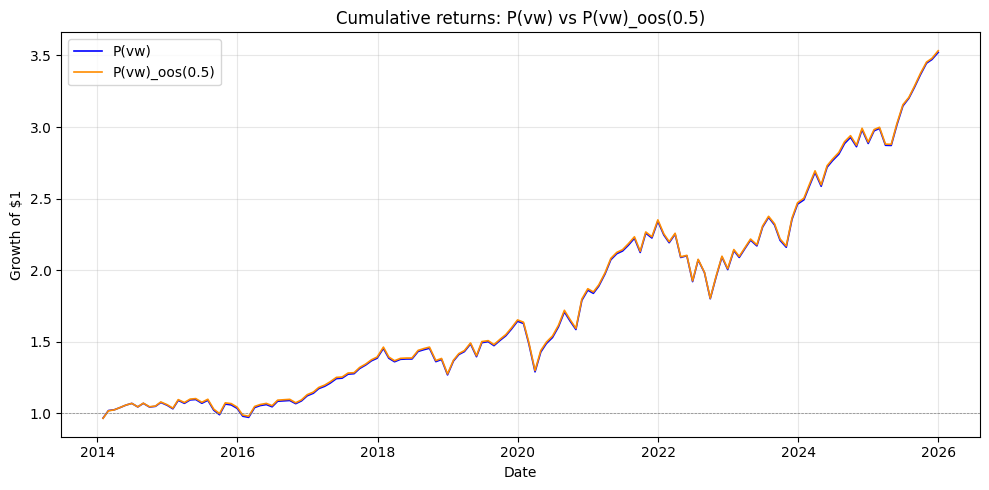

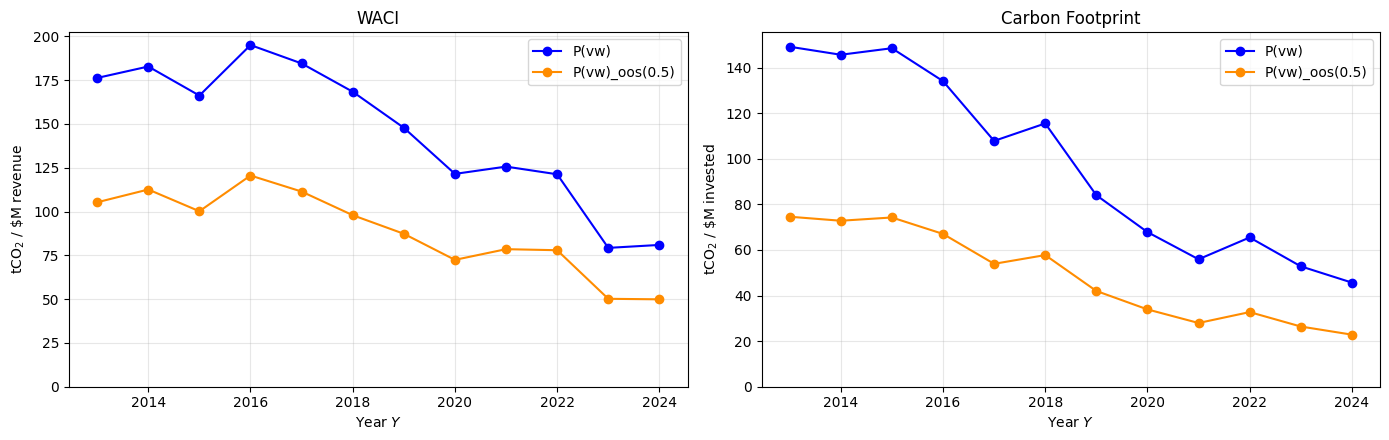

In [10]:
# §3.3 — Tracking-error minimization with CF <= 0.5 * CF^(vw).
# min (w-w_vw)' Sigma (w-w_vw)  s.t.  cf_coef . w <= 0.5 * CF_vw,  sum w = 1,  w >= 0.
# Minimizing TE^2 is equivalent to minimizing TE (sqrt is monotone).

def solve_te_constrained(cov, w_vw, cf_coef, cf_limit):
    n = cov.shape[0]
    w = cp.Variable(n)
    diff = w - w_vw
    # Tiny internal margin: the post-solve clip(>=0)+renormalize step can nudge
    # realized CF up by ~1e-12 of cf_limit. Solving against (1 - 1e-6) * cf_limit
    # guarantees the binding constraint holds after that step.
    cf_limit_internal = cf_limit * (1.0 - 1e-6)
    prob = cp.Problem(
        cp.Minimize(cp.quad_form(diff, cp.psd_wrap(cov))),
        [cp.sum(w) == 1, w >= 0, cf_coef @ w <= cf_limit_internal],
    )
    prob.solve(solver=cp.OSQP, verbose=False, eps_abs=1e-8, eps_rel=1e-8, max_iter=50_000)
    if prob.status not in ["optimal", "optimal_inaccurate"]:
        raise RuntimeError(f"TE-constrained solver failed: {prob.status}")
    weights = np.clip(np.array(w.value).flatten(), 0, None)
    return weights / weights.sum()

te05_weights_rows = []
te05_return_rows  = []
te05_summary_rows = []

for year in range(START_YEAR, END_YEAR + 1):
    investment_year = year + 1

    investable_isins = investment_set.loc[
        (investment_set["screen_year"] == year) & investment_set["investable_for_next_year"],
        "ISIN"].tolist()
    if not investable_isins:
        continue

    window_cols = get_trailing_window_cols(ret_month_cols, end_year=year, window_years=WINDOW_YEARS)
    yec = get_december_col(mv_month_cols, year)
    if yec is None:
        continue

    mu, cov, valid_isins = estimate_moments(ri_ret_by_isin, investable_isins, window_cols)
    if not valid_isins:
        continue

    cap_y = mv_by_isin[yec].reindex(valid_isins)
    co2_y = co2_by_isin[year].reindex(valid_isins) if year in co2_by_isin.columns else pd.Series(np.nan, index=valid_isins)
    cf_coef = (co2_y / cap_y).values
    if not np.all(np.isfinite(cf_coef)):
        n_bad = int(np.sum(~np.isfinite(cf_coef)))
        raise RuntimeError(f"{year}: {n_bad} valid_isins missing CO2 or Cap.")

    # VW benchmark weights over the cov universe (the simplex on which we optimise)
    w_vw_arr = (cap_y / cap_y.sum()).values

    # CF of the VW benchmark over the FULL investable set (spec definition):
    #   CF^(vw)_Y = (1/Cap_Y) * sum_i E_{i,Y}
    cap_inv = mv_by_isin[yec].reindex(investable_isins)
    co2_inv = co2_by_isin[year].reindex(investable_isins)
    cf_vw_full = float(co2_inv.sum(skipna=True) / cap_inv.sum(skipna=True))
    cf_limit   = 0.5 * cf_vw_full

    w_te        = solve_te_constrained(cov, w_vw_arr, cf_coef, cf_limit)
    realized_cf = float(cf_coef @ w_te)
    realized_te = float(np.sqrt((w_te - w_vw_arr) @ cov @ (w_te - w_vw_arr)))

    for isin, w in zip(valid_isins, w_te):
        te05_weights_rows.append({"screen_year": year, "investment_year": investment_year,
                                  "ISIN": isin, "weight": w})

    te05_summary_rows.append({"screen_year": year, "investment_year": investment_year,
                              "n_assets": len(valid_isins),
                              "cf_vw_full": cf_vw_full, "cf_limit": cf_limit,
                              "cf_realized": realized_cf,
                              "binding": bool(np.isclose(realized_cf, cf_limit, atol=1e-4)),
                              "tracking_error": realized_te,
                              "max_weight": float(w_te.max())})

    inv_cols  = get_investment_year_cols(ret_month_cols, investment_year)
    if not inv_cols:
        continue
    inv_dates = [pd.Timestamp(c) for c in inv_cols]
    current_w = pd.Series(w_te, index=valid_isins)

    for col, dt in zip(inv_cols, inv_dates):
        month_rets = ri_ret_by_isin.reindex(valid_isins)[col].apply(pd.to_numeric, errors="coerce")
        valid_mask = month_rets.notna()
        if not valid_mask.any() or current_w[valid_mask].sum() <= 1e-12:
            rp = 0.0
        else:
            w_active = current_w[valid_mask] / current_w[valid_mask].sum()
            rp       = float((w_active * month_rets[valid_mask]).sum())
            grown    = current_w[valid_mask] * (1.0 + month_rets[valid_mask])
            current_w = current_w.copy() * 0.0
            current_w[valid_mask] = grown / grown.sum()
        te05_return_rows.append({"date": dt, "Rp_te05": rp})

te05_weights_by_year = pd.DataFrame(te05_weights_rows)
te05_monthly_returns = pd.DataFrame(te05_return_rows).sort_values("date").reset_index(drop=True)
te05_summary_by_year = pd.DataFrame(te05_summary_rows)

te05_weights_by_year.to_csv(OUT_DIR / "te05_weights_by_year.csv", index=False)
te05_monthly_returns.to_csv(OUT_DIR / "te05_monthly_returns.csv", index=False)
te05_summary_by_year.to_csv(OUT_DIR / "te05_summary_by_year.csv", index=False)

assert te05_summary_by_year["cf_realized"].le(te05_summary_by_year["cf_limit"] + 1e-4).all()

# ---- Performance comparison vs P(vw) ----
vw_idx   = compare_df["Rp_vw"]
te05_idx = te05_monthly_returns.set_index("date")["Rp_te05"]
common_dates = vw_idx.index.intersection(te05_idx.index)

stats_vw   = summary_stats(vw_idx.loc[common_dates],   "P(vw)",          rf_monthly=rf_monthly_avg)
stats_te05 = summary_stats(te05_idx.loc[common_dates], "P(vw)_oos(0.5)", rf_monthly=rf_monthly_avg)

perf = pd.DataFrame([stats_vw, stats_te05])[
    ["portfolio","n_months","ann_mean_return","ann_volatility","sharpe_ratio","min_monthly_return","max_monthly_return"]
].rename(columns={"portfolio":"Portfolio","n_months":"T",
                  "ann_mean_return":"Ann. Mean","ann_volatility":"Ann. Vol",
                  "sharpe_ratio":"Sharpe","min_monthly_return":"Min","max_monthly_return":"Max"})
display_perf = perf.copy()
for c in ["Ann. Mean","Ann. Vol","Min","Max"]:
    display_perf[c] = display_perf[c].map(lambda x: f"{x:.2%}")
display_perf["Sharpe"] = display_perf["Sharpe"].map(lambda x: f"{x:.3f}")

from IPython.display import display
display(display_perf)
perf.to_csv(OUT_DIR / "vw_vs_te05_performance_summary.csv", index=False)

# ---- Carbon comparison ----
carbon_rows = []
for year in range(START_YEAR, END_YEAR + 1):
    yec = get_december_col(mv_month_cols, year)
    if yec is None or year not in co2_by_isin.columns:
        continue
    cap_y, co2_y, ci_y = mv_by_isin[yec], co2_by_isin[year], ci_table[year]

    investable_isins = investment_set.loc[
        (investment_set["screen_year"] == year) & investment_set["investable_for_next_year"], "ISIN"
    ].tolist()
    cap_inv = cap_y.reindex(investable_isins).dropna()
    if cap_inv.empty:
        continue
    w_vw_inv = cap_inv / cap_inv.sum()
    waci_vw  = float((w_vw_inv * ci_y.reindex(w_vw_inv.index)).sum(skipna=True))
    cf_vw    = float(co2_y.reindex(investable_isins).sum(skipna=True) / cap_inv.sum())

    w_te = te05_weights_by_year.loc[te05_weights_by_year["screen_year"] == year].set_index("ISIN")["weight"]
    if w_te.empty:
        waci_te = cf_te = np.nan
    else:
        ci_a  = ci_y.reindex(w_te.index)
        co2_a = co2_y.reindex(w_te.index)
        cap_a = cap_y.reindex(w_te.index)
        waci_te = float((w_te * ci_a).sum(skipna=True))
        cf_te   = float((w_te * (co2_a / cap_a)).sum(skipna=True))

    carbon_rows.append({"Year": year, "WACI_VW": waci_vw, "WACI_TE05": waci_te,
                        "CF_VW": cf_vw, "CF_TE05": cf_te})

carbon_te = pd.DataFrame(carbon_rows)
carbon_te["WACI_change_%"] = (carbon_te["WACI_TE05"] / carbon_te["WACI_VW"] - 1) * 100
carbon_te["CF_change_%"]   = (carbon_te["CF_TE05"]   / carbon_te["CF_VW"]   - 1) * 100
display(carbon_te.round(2))
carbon_te.to_csv(OUT_DIR / "vw_vs_te05_carbon.csv", index=False)

# ---- Plots ----
cum_vw   = (1 + vw_idx.loc[common_dates]).cumprod()
cum_te05 = (1 + te05_idx.loc[common_dates]).cumprod()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cum_vw.index,   cum_vw,   linewidth=1.2, label="P(vw)",          color="blue")
ax.plot(cum_te05.index, cum_te05, linewidth=1.2, label="P(vw)_oos(0.5)", color="darkorange")
ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.5)
ax.set_title("Cumulative returns: P(vw) vs P(vw)_oos(0.5)")
ax.set_xlabel("Date"); ax.set_ylabel("Growth of $1")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "vw_vs_te05_cumulative_returns.png", dpi=300, bbox_inches="tight"); plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
ax1.plot(carbon_te["Year"], carbon_te["WACI_VW"],   "-o", label="P(vw)",          color="blue")
ax1.plot(carbon_te["Year"], carbon_te["WACI_TE05"], "-o", label="P(vw)_oos(0.5)", color="darkorange")
ax1.set_title("WACI"); ax1.set_ylabel(r"tCO$_2$ / \$M revenue"); ax1.set_xlabel("Year $Y$"); ax1.legend(); ax1.grid(alpha=0.3); ax1.set_ylim(bottom=0)
ax2.plot(carbon_te["Year"], carbon_te["CF_VW"],   "-o", label="P(vw)",          color="blue")
ax2.plot(carbon_te["Year"], carbon_te["CF_TE05"], "-o", label="P(vw)_oos(0.5)", color="darkorange")
ax2.set_title("Carbon Footprint"); ax2.set_ylabel(r"tCO$_2$ / \$M invested"); ax2.set_xlabel("Year $Y$"); ax2.legend(); ax2.grid(alpha=0.3); ax2.set_ylim(bottom=0)
plt.tight_layout()
fig.savefig(OUT_DIR / "vw_vs_te05_carbon_plot.png", dpi=300, bbox_inches="tight"); plt.show()

## 3.4 Portfolio Comparison

We compare all four portfolios — P(mv)\_oos, P(mv)\_oos(0.5), P(vw)\_oos, P(vw)\_oos(0.5) — on financial performance and carbon reduction over Jan 2014\u2013Dec 2025.

,P(mv)_oos,P(mv)_oos(0.5),P(vw),P(vw)_oos(0.5)
Ann. return,7.35%,7.32%,11.54%,11.56%
Ann. volatility,11.58%,11.52%,14.19%,14.17%
Sharpe ratio,0.484,0.483,0.690,0.693
Min monthly,-11.77%,-11.27%,-13.13%,-13.05%
Max monthly,10.74%,10.87%,12.88%,12.88%
Avg WACI,374.3,174.9,145.8,88.7
Avg CF,167.7,83.9,97.7,48.8



Decarbonization cost (bps of ann return per % CF reduction):
  MVP -> MVP(0.5): +0.08 bps/%  (positive = constrained gives up return)
  VW  -> VW(0.5) : -0.05 bps/%


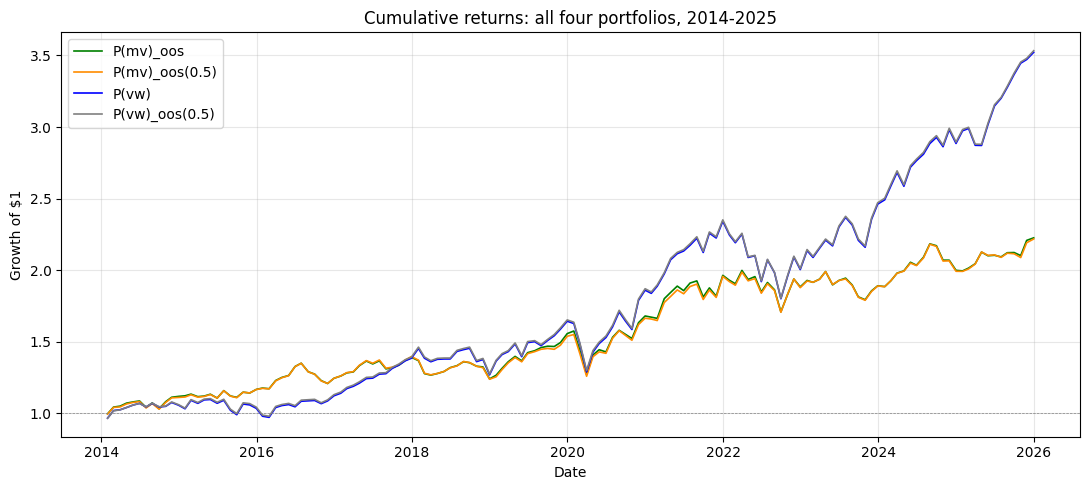

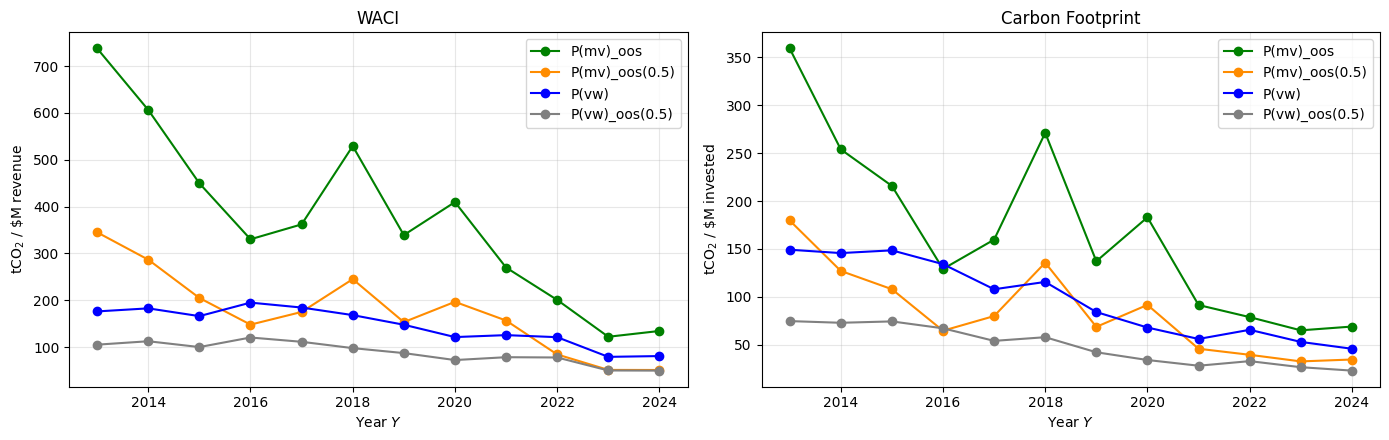

In [11]:
# §3.4 — four-way comparison.
# Reads carbon tables produced in §3.1 (carbon_summary), §3.2 (carbon_compare),
# §3.3 (carbon_te), and the four return series.

mvp_idx   = mvp_monthly_returns.set_index("date")["Rp_mvp"]
vw_idx    = vw_monthly_returns.set_index("date")["Rp_vw"]
mvp05_idx = mvp05_monthly_returns.set_index("date")["Rp_mvp05"]
te05_idx  = te05_monthly_returns.set_index("date")["Rp_te05"]

idx = (mvp_idx.index.intersection(vw_idx.index)
       .intersection(mvp05_idx.index).intersection(te05_idx.index))
mvp, vw, mvp05, te05 = mvp_idx.loc[idx], vw_idx.loc[idx], mvp05_idx.loc[idx], te05_idx.loc[idx]

stats = pd.DataFrame([
    summary_stats(mvp,   "P(mv)_oos",      rf_monthly=rf_monthly_avg),
    summary_stats(mvp05, "P(mv)_oos(0.5)", rf_monthly=rf_monthly_avg),
    summary_stats(vw,    "P(vw)",          rf_monthly=rf_monthly_avg),
    summary_stats(te05,  "P(vw)_oos(0.5)", rf_monthly=rf_monthly_avg),
]).set_index("portfolio")

avg_waci = {"P(mv)_oos":      carbon_summary["WACI_MVP"].mean(),
            "P(mv)_oos(0.5)": carbon_compare["WACI_MVP05"].mean(),
            "P(vw)":          carbon_summary["WACI_VW"].mean(),
            "P(vw)_oos(0.5)": carbon_te["WACI_TE05"].mean()}
avg_cf   = {"P(mv)_oos":      carbon_summary["CF_MVP"].mean(),
            "P(mv)_oos(0.5)": carbon_compare["CF_MVP05"].mean(),
            "P(vw)":          carbon_summary["CF_VW"].mean(),
            "P(vw)_oos(0.5)": carbon_te["CF_TE05"].mean()}

# Cost of decarbonization: bps of ann return given up vs the unconstrained
# sibling, per percent of CF reduction. Negative = constrained earns more.
def cost_bps_per_pct(constrained_ret, base_ret, cf_c, cf_b):
    if cf_b <= 0: return np.nan
    return -(constrained_ret - base_ret) * 1e4 / abs((cf_c / cf_b - 1) * 100)

cost_mvp = cost_bps_per_pct(stats.loc["P(mv)_oos(0.5)", "ann_mean_return"],
                            stats.loc["P(mv)_oos",      "ann_mean_return"],
                            avg_cf["P(mv)_oos(0.5)"], avg_cf["P(mv)_oos"])
cost_vw  = cost_bps_per_pct(stats.loc["P(vw)_oos(0.5)", "ann_mean_return"],
                            stats.loc["P(vw)",          "ann_mean_return"],
                            avg_cf["P(vw)_oos(0.5)"], avg_cf["P(vw)"])

table = pd.DataFrame({p: [
    stats.loc[p, "ann_mean_return"], stats.loc[p, "ann_volatility"],
    stats.loc[p, "sharpe_ratio"], stats.loc[p, "min_monthly_return"],
    stats.loc[p, "max_monthly_return"], avg_waci[p], avg_cf[p],
] for p in ["P(mv)_oos","P(mv)_oos(0.5)","P(vw)","P(vw)_oos(0.5)"]},
    index=["Ann. return","Ann. volatility","Sharpe ratio",
           "Min monthly","Max monthly","Avg WACI","Avg CF"])

display_tbl = table.astype(object)
for r in ["Ann. return","Ann. volatility","Min monthly","Max monthly"]:
    display_tbl.loc[r] = display_tbl.loc[r].map(lambda x: f"{x:.2%}")
display_tbl.loc["Sharpe ratio"] = display_tbl.loc["Sharpe ratio"].map(lambda x: f"{x:.3f}")
display_tbl.loc[["Avg WACI","Avg CF"]] = display_tbl.loc[["Avg WACI","Avg CF"]].map(lambda x: f"{x:,.1f}")

from IPython.display import display
display(display_tbl)

print(f"\nDecarbonization cost (bps of ann return per % CF reduction):")
print(f"  MVP -> MVP(0.5): {cost_mvp:+.2f} bps/%  (positive = constrained gives up return)")
print(f"  VW  -> VW(0.5) : {cost_vw:+.2f} bps/%")

table.to_csv(OUT_DIR / "section34_comparison_table.csv")

# Cumulative returns: all four
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(idx, (1+mvp).cumprod(),   color="green",      linewidth=1.2, label="P(mv)_oos")
ax.plot(idx, (1+mvp05).cumprod(), color="darkorange", linewidth=1.2, label="P(mv)_oos(0.5)")
ax.plot(idx, (1+vw).cumprod(),    color="blue",       linewidth=1.2, label="P(vw)")
ax.plot(idx, (1+te05).cumprod(),  color="gray",     linewidth=1.2, label="P(vw)_oos(0.5)")
ax.axhline(1, color="grey", linestyle="--", linewidth=0.5)
ax.set_title("Cumulative returns: all four portfolios, 2014-2025")
ax.set_xlabel("Date"); ax.set_ylabel("Growth of $1")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / "section34_cumulative_returns.png", dpi=300, bbox_inches="tight"); plt.show()

# WACI and CF — log scale because the MVP family is ~10x the VW family
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
ax1.plot(carbon_summary["Year"], carbon_summary["WACI_MVP"],  "-o", color="green",      label="P(mv)_oos")
ax1.plot(carbon_compare["Year"], carbon_compare["WACI_MVP05"],"-o", color="darkorange", label="P(mv)_oos(0.5)")
ax1.plot(carbon_summary["Year"], carbon_summary["WACI_VW"],   "-o", color="blue",       label="P(vw)")
ax1.plot(carbon_te["Year"],      carbon_te["WACI_TE05"],      "-o", color="gray",     label="P(vw)_oos(0.5)")
ax1.set_title("WACI"); ax1.set_ylabel(r"tCO$_2$ / \$M revenue"); ax1.set_xlabel("Year $Y$")
ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(carbon_summary["Year"], carbon_summary["CF_MVP"],   "-o", color="green",      label="P(mv)_oos")
ax2.plot(carbon_compare["Year"], carbon_compare["CF_MVP05"], "-o", color="darkorange", label="P(mv)_oos(0.5)")
ax2.plot(carbon_summary["Year"], carbon_summary["CF_VW"],    "-o", color="blue",       label="P(vw)")
ax2.plot(carbon_te["Year"],      carbon_te["CF_TE05"],       "-o", color="gray",     label="P(vw)_oos(0.5)")
ax2.set_title("Carbon Footprint"); ax2.set_ylabel(r"tCO$_2$ / \$M invested"); ax2.set_xlabel("Year $Y$")
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / "section34_carbon_comparison.png", dpi=300, bbox_inches="tight"); plt.show()

## 4.1 Net Zero Portfolio — P(vw)\_oos(NZ)

We construct a **Net Zero** portfolio that stays as close as possible to the
value-weighted benchmark while reducing its carbon footprint by 10 % per year,
compounding from the 2013 VW baseline:

$$
\min_{\alpha_Y} \; TE(p,Y)^2 = (\alpha_Y - \alpha^{(vw)}_Y)^\top
\hat{\Sigma}_Y (\alpha_Y - \alpha^{(vw)}_Y)
$$

$$
\text{s.t.} \quad CF^{(p)}_Y \le (1-\theta)^{Y-Y_0+1} \cdot CF^{(vw)}_{Y_0},
\quad \alpha_Y^\top e = 1, \quad \alpha_{i,Y} \ge 0
$$

with $\theta = 10\%$, $Y_0 = 2013$ (first screen year), and
$CF^{(vw)}_{Y_0}$ the realised carbon footprint of the VW portfolio at end-2013.
The resulting portfolio is denoted **P(vw)\_oos(NZ)**.


,Year,WACI_VW,WACI_NZ,CF_VW,CF_NZ,CF_NZ_target,WACI_NZ_target_proxy
0,2013,176.27,167.82,149.13,134.22,134.22,158.65
1,2014,182.80,168.66,145.61,120.80,120.80,142.78
2,2015,166.21,140.80,148.48,108.72,108.72,128.50
3,2016,195.05,165.84,134.05,97.84,97.84,115.65
4,2017,184.56,166.74,107.82,88.06,88.06,104.09
5,2018,168.39,134.11,115.48,79.25,79.25,93.68
6,2019,147.82,135.57,84.01,71.33,71.33,84.31
7,2020,121.50,118.15,67.83,64.20,64.20,75.88
8,2021,125.66,125.27,55.91,55.39,57.78,68.29
9,2022,121.28,110.44,65.47,52.00,52.00,61.46


,Portfolio,T,Ann. Mean,Ann. Vol,Sharpe,Min,Max
0,P(vw),144,11.54%,14.19%,0.690,-13.13%,12.88%
1,P(vw)_oos(NZ),144,11.61%,14.17%,0.696,-13.07%,12.83%


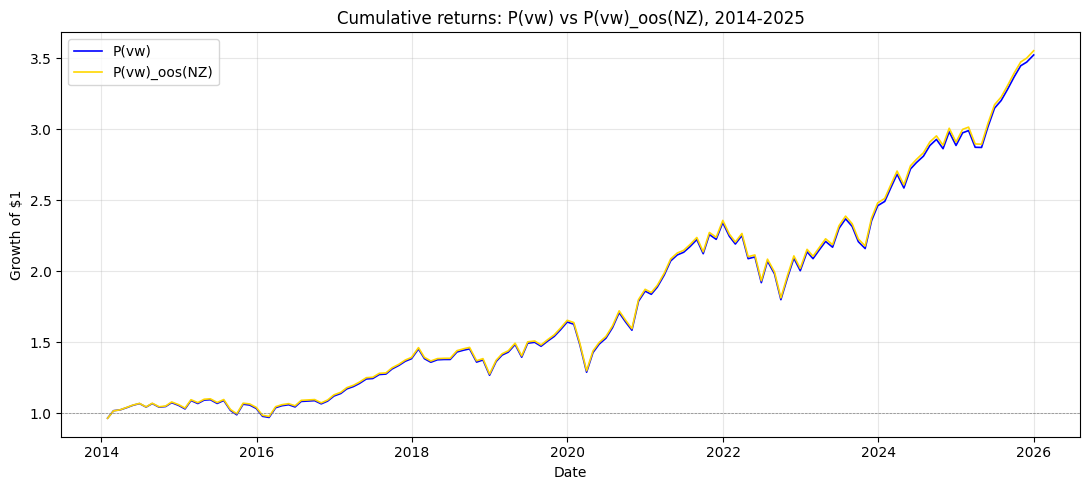

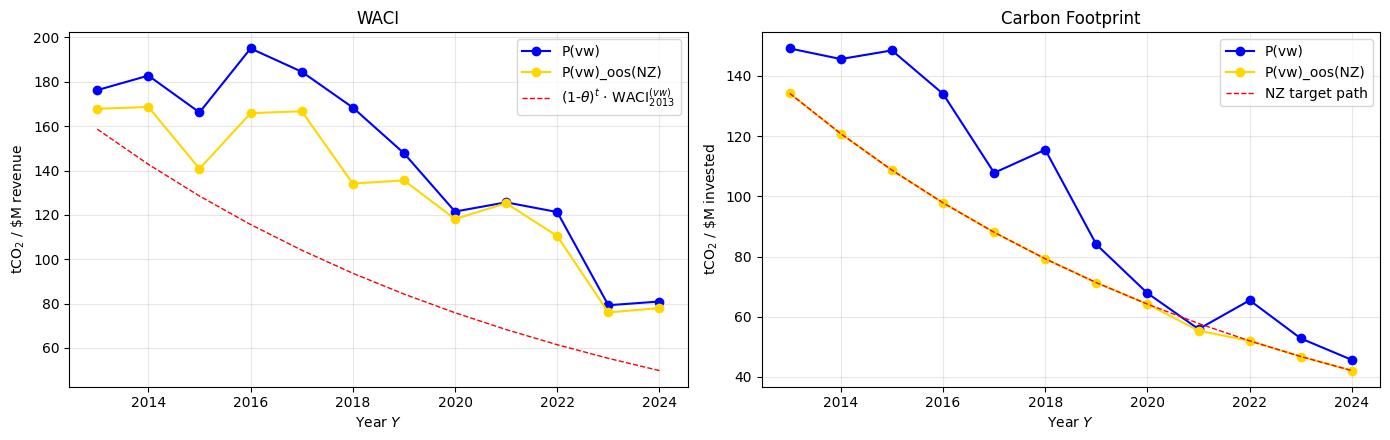

In [12]:
# §4.1 — P(vw)_oos(NZ): TE minimization with a 10%/yr cumulative carbon cut
# anchored at CF^(vw)_2013. Otherwise passive investor (same QP form as §3.3).

THETA = 0.10
Y0    = 2013

cf_vw_Y0   = float(carbon_summary.loc[carbon_summary["Year"] == Y0, "CF_VW"].iloc[0])
waci_vw_Y0 = float(carbon_summary.loc[carbon_summary["Year"] == Y0, "WACI_VW"].iloc[0])


def solve_te_constrained(cov, w_vw, cf_coef, cf_limit):
    n = cov.shape[0]; w = cp.Variable(n)
    diff = w - w_vw
    cf_limit_internal = cf_limit * (1.0 - 1e-6)
    prob = cp.Problem(
        cp.Minimize(cp.quad_form(diff, cp.psd_wrap(cov))),
        [cp.sum(w) == 1, w >= 0, cf_coef @ w <= cf_limit_internal],
    )
    prob.solve(solver=cp.OSQP, verbose=False, eps_abs=1e-8, eps_rel=1e-8, max_iter=50_000)
    if prob.status not in ["optimal", "optimal_inaccurate"]:
        raise RuntimeError(f"NZ solver failed: {prob.status}")
    weights = np.clip(np.array(w.value).flatten(), 0, None)
    return weights / weights.sum()

nz_weights_rows = []
nz_return_rows  = []
nz_summary_rows = []

for year in range(START_YEAR, END_YEAR + 1):
    investment_year = year + 1
    cf_limit = (1 - THETA) ** (year - Y0 + 1) * cf_vw_Y0

    investable_isins = investment_set.loc[
        (investment_set["screen_year"] == year) & investment_set["investable_for_next_year"],
        "ISIN"].tolist()
    if not investable_isins: continue

    window_cols = get_trailing_window_cols(ret_month_cols, end_year=year, window_years=WINDOW_YEARS)
    yec = get_december_col(mv_month_cols, year)
    if yec is None: continue

    mu, cov, valid_isins = estimate_moments(ri_ret_by_isin, investable_isins, window_cols)
    if not valid_isins: continue

    cap_y = mv_by_isin[yec].reindex(valid_isins)
    co2_y = co2_by_isin[year].reindex(valid_isins) if year in co2_by_isin.columns else pd.Series(np.nan, index=valid_isins)
    cf_coef = (co2_y / cap_y).values
    if not np.all(np.isfinite(cf_coef)):
        n_bad = int(np.sum(~np.isfinite(cf_coef)))
        raise RuntimeError(f"{year}: {n_bad} valid_isins missing CO2 or Cap.")

    w_vw_arr             = (cap_y / cap_y.sum()).values
    cf_vw_y_unconstrained = float(cf_coef @ w_vw_arr)

    w_nz        = solve_te_constrained(cov, w_vw_arr, cf_coef, cf_limit)
    realized_cf = float(cf_coef @ w_nz)
    realized_te = float(np.sqrt((w_nz - w_vw_arr) @ cov @ (w_nz - w_vw_arr)))

    for isin, w in zip(valid_isins, w_nz):
        nz_weights_rows.append({"screen_year": year, "investment_year": investment_year,
                                "ISIN": isin, "weight": w})
    nz_summary_rows.append({"screen_year": year, "investment_year": investment_year,
                            "n_assets": len(valid_isins),
                            "cf_vw_unconstrained": cf_vw_y_unconstrained,
                            "cf_limit": cf_limit, "cf_realized": realized_cf,
                            "binding": cf_vw_y_unconstrained > cf_limit + 1e-9,
                            "tracking_error": realized_te,
                            "max_weight": float(w_nz.max())})

    inv_cols  = get_investment_year_cols(ret_month_cols, investment_year)
    if not inv_cols: continue
    inv_dates = [pd.Timestamp(c) for c in inv_cols]
    current_w = pd.Series(w_nz, index=valid_isins)

    for col, dt in zip(inv_cols, inv_dates):
        month_rets = ri_ret_by_isin.reindex(valid_isins)[col].apply(pd.to_numeric, errors="coerce")
        valid_mask = month_rets.notna()
        if not valid_mask.any() or current_w[valid_mask].sum() <= 1e-12:
            rp = 0.0
        else:
            w_active = current_w[valid_mask] / current_w[valid_mask].sum()
            rp       = float((w_active * month_rets[valid_mask]).sum())
            grown    = current_w[valid_mask] * (1.0 + month_rets[valid_mask])
            current_w = current_w.copy() * 0.0
            current_w[valid_mask] = grown / grown.sum()
        nz_return_rows.append({"date": dt, "Rp_nz": rp})

nz_weights_by_year = pd.DataFrame(nz_weights_rows)
nz_monthly_returns = pd.DataFrame(nz_return_rows).sort_values("date").reset_index(drop=True)
nz_summary_by_year = pd.DataFrame(nz_summary_rows)

nz_weights_by_year.to_csv(OUT_DIR / "nz_weights_by_year.csv", index=False)
nz_monthly_returns.to_csv(OUT_DIR / "nz_monthly_returns.csv", index=False)
nz_summary_by_year.to_csv(OUT_DIR / "nz_summary_by_year.csv", index=False)
assert nz_summary_by_year["cf_realized"].le(nz_summary_by_year["cf_limit"] + 1e-4).all()

# ---- Per-year carbon table ----
carbon_nz_rows = []
for year in range(START_YEAR, END_YEAR + 1):
    yec = get_december_col(mv_month_cols, year)
    if yec is None or year not in co2_by_isin.columns: continue
    cap_y, co2_y, ci_y = mv_by_isin[yec], co2_by_isin[year], ci_table[year]

    investable_isins = investment_set.loc[
        (investment_set["screen_year"] == year) & investment_set["investable_for_next_year"], "ISIN"
    ].tolist()
    cap_inv = cap_y.reindex(investable_isins).dropna()
    w_vw_inv = cap_inv / cap_inv.sum()
    waci_vw  = float((w_vw_inv * ci_y.reindex(w_vw_inv.index)).sum(skipna=True))
    cf_vw    = float(co2_y.reindex(investable_isins).sum(skipna=True) / cap_inv.sum())

    w_nz = nz_weights_by_year.loc[nz_weights_by_year["screen_year"] == year].set_index("ISIN")["weight"]
    if w_nz.empty:
        waci_nz = cf_nz = np.nan
    else:
        ci_a, co2_a, cap_a = ci_y.reindex(w_nz.index), co2_y.reindex(w_nz.index), cap_y.reindex(w_nz.index)
        waci_nz = float((w_nz * ci_a).sum(skipna=True))
        cf_nz   = float((w_nz * (co2_a / cap_a)).sum(skipna=True))

    carbon_nz_rows.append({"Year": year, "WACI_VW": waci_vw, "WACI_NZ": waci_nz,
                           "CF_VW": cf_vw, "CF_NZ": cf_nz,
                           "CF_NZ_target": (1 - THETA)**(year - Y0 + 1) * cf_vw_Y0,
                           "WACI_NZ_target_proxy": (1 - THETA)**(year - Y0 + 1) * waci_vw_Y0})

carbon_nz = pd.DataFrame(carbon_nz_rows)
carbon_nz.to_csv(OUT_DIR / "vw_vs_nz_carbon.csv", index=False)

from IPython.display import display
display(carbon_nz.round(2))

# ---- Performance comparison ----
vw_idx = vw_monthly_returns.set_index("date")["Rp_vw"]
nz_idx = nz_monthly_returns.set_index("date")["Rp_nz"]
common_dates = vw_idx.index.intersection(nz_idx.index)

stats_vw = summary_stats(vw_idx.loc[common_dates], "P(vw)",         rf_monthly=rf_monthly_avg)
stats_nz = summary_stats(nz_idx.loc[common_dates], "P(vw)_oos(NZ)", rf_monthly=rf_monthly_avg)

perf = pd.DataFrame([stats_vw, stats_nz])[
    ["portfolio","n_months","ann_mean_return","ann_volatility","sharpe_ratio","min_monthly_return","max_monthly_return"]
].rename(columns={"portfolio":"Portfolio","n_months":"T",
                  "ann_mean_return":"Ann. Mean","ann_volatility":"Ann. Vol",
                  "sharpe_ratio":"Sharpe","min_monthly_return":"Min","max_monthly_return":"Max"})
display_perf = perf.astype(object).copy()
for c in ["Ann. Mean","Ann. Vol","Min","Max"]:
    display_perf[c] = display_perf[c].map(lambda x: f"{x:.2%}")
display_perf["Sharpe"] = display_perf["Sharpe"].map(lambda x: f"{x:.3f}")

display(display_perf)
perf.to_csv(OUT_DIR / "vw_vs_nz_performance_summary.csv", index=False)

# ---- Plots ----
cum_vw = (1 + vw_idx.loc[common_dates]).cumprod()
cum_nz = (1 + nz_idx.loc[common_dates]).cumprod()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(cum_vw.index, cum_vw, color="blue", linewidth=1.2, label="P(vw)")
ax.plot(cum_nz.index, cum_nz, color="gold", linewidth=1.2, label="P(vw)_oos(NZ)")
ax.axhline(1, color="grey", linestyle="--", linewidth=0.5)
ax.set_title("Cumulative returns: P(vw) vs P(vw)_oos(NZ), 2014-2025")
ax.set_xlabel("Date"); ax.set_ylabel("Growth of $1")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / "vw_vs_nz_cumulative_returns.png", dpi=300, bbox_inches="tight"); plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
ax1.plot(carbon_nz["Year"], carbon_nz["WACI_VW"], "-o", color="blue", label="P(vw)")
ax1.plot(carbon_nz["Year"], carbon_nz["WACI_NZ"], "-o", color="gold", label="P(vw)_oos(NZ)")
ax1.plot(carbon_nz["Year"], carbon_nz["WACI_NZ_target_proxy"], "r--", linewidth=1, label=r"(1-$\theta$)$^t$ $\cdot$ WACI$^{(vw)}_{2013}$")
ax1.set_title("WACI"); ax1.set_ylabel(r"tCO$_2$ / \$M revenue"); ax1.set_xlabel("Year $Y$")
ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(carbon_nz["Year"], carbon_nz["CF_VW"],        "-o", color="blue", label="P(vw)")
ax2.plot(carbon_nz["Year"], carbon_nz["CF_NZ"],        "-o", color="gold", label="P(vw)_oos(NZ)")
ax2.plot(carbon_nz["Year"], carbon_nz["CF_NZ_target"], "r--", linewidth=1, label="NZ target path")
ax2.set_title("Carbon Footprint"); ax2.set_ylabel(r"tCO$_2$ / \$M invested"); ax2.set_xlabel("Year $Y$")
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / "vw_vs_nz_carbon_plot.png", dpi=300, bbox_inches="tight"); plt.show()

## 4.2 Comparison of Value-Weighted Portfolios

We compare the three value-weighted-based portfolios over the full out-of-sample
period (Jan 2014 – Dec 2025):

| Portfolio | Strategy |
|---|---|
| P(vw)\_oos | Passive VW benchmark — no decarbonisation |
| P(vw)\_oos(0.5) | One-time 50 % CF reduction (Section 3.3) |
| P(vw)\_oos(NZ) | Net Zero: 10 %/yr cumulative CF reduction (Section 4.1) |

We report annualised performance statistics, a cumulative return chart for all
three portfolios, and the evolution of carbon footprints, including the NZ target path.


,P(vw),P(vw)_oos(0.5),P(vw)_oos(NZ)
Ann. return,11.54%,11.56%,11.61%
Ann. volatility,14.19%,14.17%,14.17%
Sharpe ratio,0.690,0.693,0.696
Min monthly,-13.13%,-13.05%,-13.07%
Max monthly,12.88%,12.88%,12.83%
Avg WACI,145.8,88.7,132.3
Avg CF,97.7,48.8,80.1
Return vs P(vw) (bps/yr),+0.0,+2.3,+6.7


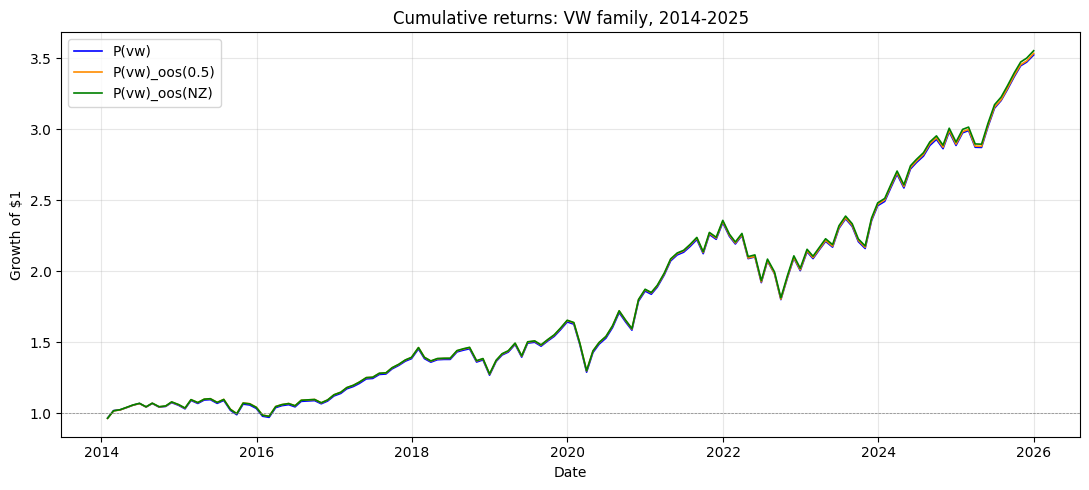

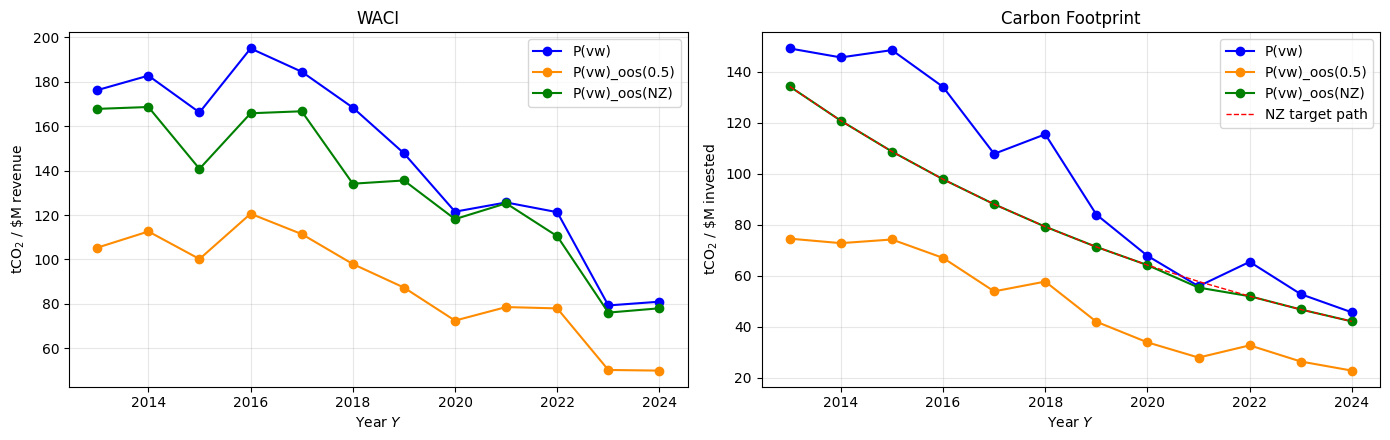

In [13]:
# §4.2 — Three-way comparison: P(vw), P(vw)_oos(0.5), P(vw)_oos(NZ).
# Reads vw_monthly_returns (§2.3), te05_monthly_returns (§3.3),
# nz_monthly_returns (§4.1), carbon_summary (§3.1), carbon_te (§3.3),
# carbon_nz (§4.1), and the NZ schedule constants from §4.1.

vw_idx   = vw_monthly_returns.set_index("date")["Rp_vw"]
te05_idx = te05_monthly_returns.set_index("date")["Rp_te05"]
nz_idx   = nz_monthly_returns.set_index("date")["Rp_nz"]

idx_all = vw_idx.index.intersection(te05_idx.index).intersection(nz_idx.index)
vw_r, te05_r, nz_r = vw_idx.loc[idx_all], te05_idx.loc[idx_all], nz_idx.loc[idx_all]

stats = pd.DataFrame([
    summary_stats(vw_r,   "P(vw)",          rf_monthly=rf_monthly_avg),
    summary_stats(te05_r, "P(vw)_oos(0.5)", rf_monthly=rf_monthly_avg),
    summary_stats(nz_r,   "P(vw)_oos(NZ)",  rf_monthly=rf_monthly_avg),
]).set_index("portfolio")

avg_waci = {"P(vw)":          carbon_summary["WACI_VW"].mean(),
            "P(vw)_oos(0.5)": carbon_te["WACI_TE05"].mean(),
            "P(vw)_oos(NZ)":  carbon_nz["WACI_NZ"].mean()}
avg_cf   = {"P(vw)":          carbon_summary["CF_VW"].mean(),
            "P(vw)_oos(0.5)": carbon_te["CF_TE05"].mean(),
            "P(vw)_oos(NZ)":  carbon_nz["CF_NZ"].mean()}

def cost_bps(p):
    return (stats.loc[p, "ann_mean_return"] - stats.loc["P(vw)", "ann_mean_return"]) * 1e4

table = pd.DataFrame({p: [
    stats.loc[p, "ann_mean_return"], stats.loc[p, "ann_volatility"],
    stats.loc[p, "sharpe_ratio"], stats.loc[p, "min_monthly_return"],
    stats.loc[p, "max_monthly_return"], avg_waci[p], avg_cf[p],
    cost_bps(p),
] for p in ["P(vw)", "P(vw)_oos(0.5)", "P(vw)_oos(NZ)"]},
    index=["Ann. return","Ann. volatility","Sharpe ratio",
           "Min monthly","Max monthly","Avg WACI","Avg CF",
           "Return vs P(vw) (bps/yr)"])

display_tbl = table.astype(object).copy()
for r in ["Ann. return","Ann. volatility","Min monthly","Max monthly"]:
    display_tbl.loc[r] = display_tbl.loc[r].map(lambda x: f"{x:.2%}")
display_tbl.loc["Sharpe ratio"]            = display_tbl.loc["Sharpe ratio"].map(lambda x: f"{x:.3f}")
display_tbl.loc[["Avg WACI","Avg CF"]]     = display_tbl.loc[["Avg WACI","Avg CF"]].map(lambda x: f"{x:,.1f}")
display_tbl.loc["Return vs P(vw) (bps/yr)"] = display_tbl.loc["Return vs P(vw) (bps/yr)"].map(lambda x: f"{x:+.1f}")

from IPython.display import display
display(display_tbl)
table.to_csv(OUT_DIR / "section42_comparison_table.csv")

# Cumulative returns: three series
cum_vw   = (1 + vw_r).cumprod()
cum_te05 = (1 + te05_r).cumprod()
cum_nz   = (1 + nz_r).cumprod()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(idx_all, cum_vw,   color="blue",       linewidth=1.2, label="P(vw)")
ax.plot(idx_all, cum_te05, color="darkorange", linewidth=1.2, label="P(vw)_oos(0.5)")
ax.plot(idx_all, cum_nz,   color="green",     linewidth=1.2, label="P(vw)_oos(NZ)")
ax.axhline(1, color="grey", linestyle="--", linewidth=0.5)
ax.set_title("Cumulative returns: VW family, 2014-2025")
ax.set_xlabel("Date"); ax.set_ylabel("Growth of $1")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / "section42_cumulative_returns.png", dpi=300, bbox_inches="tight")
plt.show()

# Combined WACI / CF — three series + NZ target
years_plot  = list(range(START_YEAR, END_YEAR + 1))
target_path = [(1 - THETA) ** (y - Y0 + 1) * cf_vw_Y0 for y in years_plot]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
ax1.plot(carbon_summary["Year"], carbon_summary["WACI_VW"], "-o", color="blue",       label="P(vw)")
ax1.plot(carbon_te["Year"],      carbon_te["WACI_TE05"],    "-o", color="darkorange", label="P(vw)_oos(0.5)")
ax1.plot(carbon_nz["Year"],      carbon_nz["WACI_NZ"],      "-o", color="green",     label="P(vw)_oos(NZ)")
ax1.set_title("WACI"); ax1.set_ylabel(r"tCO$_2$ / \$M revenue"); ax1.set_xlabel("Year $Y$")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(carbon_summary["Year"], carbon_summary["CF_VW"], "-o", color="blue",       label="P(vw)")
ax2.plot(carbon_te["Year"],      carbon_te["CF_TE05"],    "-o", color="darkorange", label="P(vw)_oos(0.5)")
ax2.plot(carbon_nz["Year"],      carbon_nz["CF_NZ"],      "-o", color="green",     label="P(vw)_oos(NZ)")
ax2.plot(years_plot, target_path, "r--", linewidth=1, label="NZ target path")
ax2.set_title("Carbon Footprint"); ax2.set_ylabel(r"tCO$_2$ / \$M invested"); ax2.set_xlabel("Year $Y$")
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / "section42_carbon.png", dpi=300, bbox_inches="tight")
plt.show()

## Top-10 Most Carbon-Intensive Firms — VW vs MVP(0.5) vs VW(NZ)

For every screen year $Y$ we identify the 10 firms with the highest Scope-1
carbon intensity (CO$_2$ / Revenue) in the investable universe and show the
weight assigned by the **VW benchmark**, the **MVP(0.5)** carbon-constrained
portfolio and the **VW(NZ)** Net-Zero portfolio — side by side per firm.

This directly answers the §3.1 requirement to identify which firms drive
carbon intensity up and how the constrained portfolios respond.


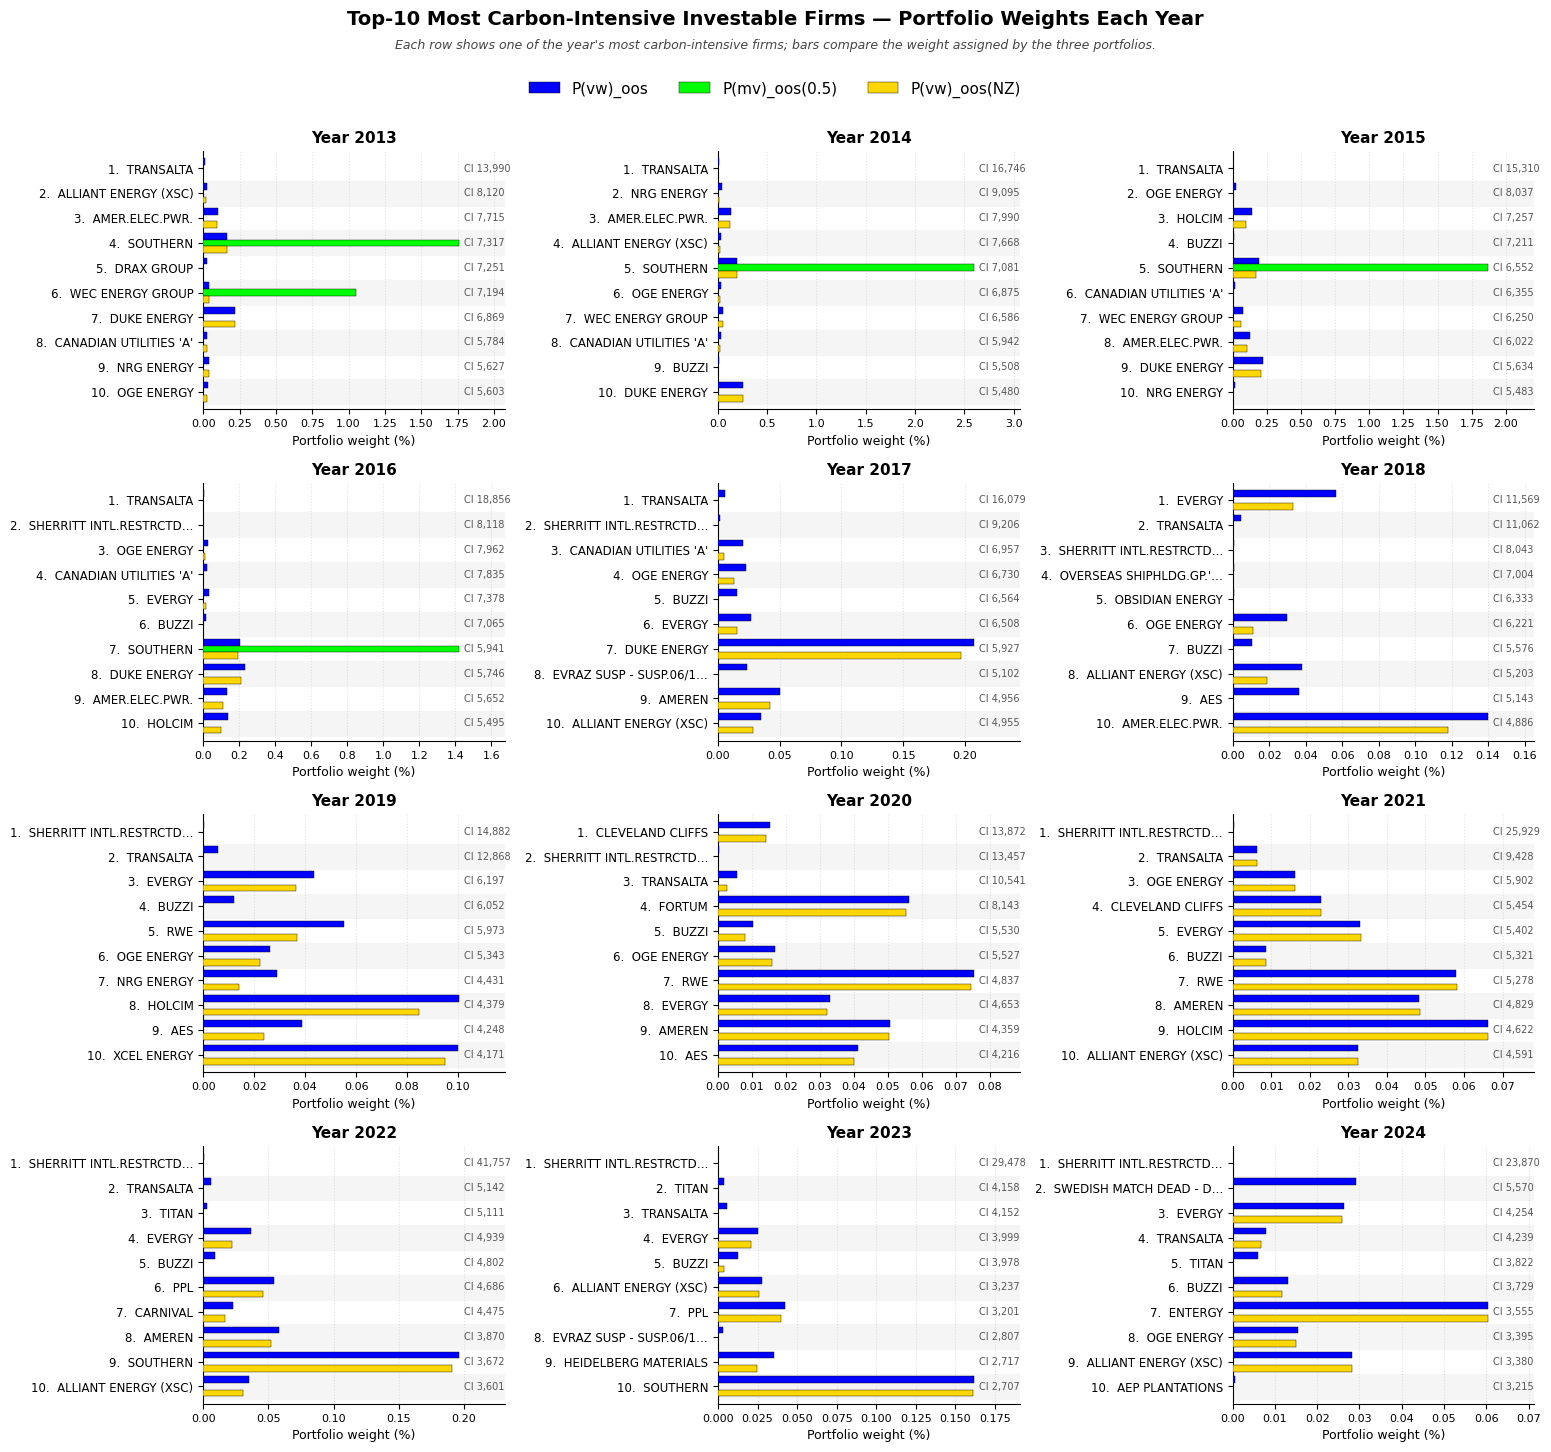


Total weight allocated to year's top-10 most carbon-intensive firms:
     P(vw)_oos P(mv)_oos(0.5) P(vw)_oos(NZ)
Year                                       
2013     0.68%          2.81%         0.63%
2014     0.78%          2.59%         0.71%
2015     0.84%          1.87%         0.65%
2016     0.82%          1.42%         0.64%
2017     0.41%          0.00%         0.30%
2018     0.32%          0.00%         0.18%
2019     0.41%          0.00%         0.31%
2020     0.30%          0.00%         0.29%
2021     0.29%          0.00%         0.29%
2022     0.42%          0.00%         0.36%
2023     0.32%          0.00%         0.28%
2024     0.19%          0.00%         0.15%


In [14]:
# Top-10 most carbon-intensive investable firms per year.
# Three grouped horizontal bars per firm: VW (blue), MVP(0.5) (green), VW(NZ) (gold).

vw_weights_rows = []
for _y in range(START_YEAR, END_YEAR + 1):
    invest_y = investment_set.loc[
        (investment_set["screen_year"] == _y) & investment_set["investable_for_next_year"],
        "ISIN"
    ].tolist()
    if not invest_y:
        continue
    cap_col = get_december_col(mv_month_cols, _y)
    if cap_col is None:
        continue
    caps = (mv_by_isin.reindex(invest_y)[cap_col]
            .apply(pd.to_numeric, errors="coerce").dropna())
    caps = caps[caps > 0]
    if caps.empty:
        continue
    for isin, w in (caps / caps.sum()).items():
        vw_weights_rows.append({"screen_year": _y, "ISIN": isin, "weight": float(w)})
vw_weights_by_year = pd.DataFrame(vw_weights_rows)

PORTFOLIOS = [
    ("P(vw)_oos",      vw_weights_by_year,    "blue"),
    ("P(mv)_oos(0.5)", mvp05_weights_by_year, "#00ff00"),
    ("P(vw)_oos(NZ)",  nz_weights_by_year,    "gold"),
]

def _top10_panel(year):
    invest_y = set(investment_set.loc[
        (investment_set["screen_year"] == year) & investment_set["investable_for_next_year"],
        "ISIN"
    ])
    if year not in ci_table.columns:
        return pd.DataFrame()
    ci_y = ci_table[year].dropna()
    ci_y = ci_y[ci_y.index.isin(invest_y)]
    if ci_y.empty:
        return pd.DataFrame()
    lookups = {label: wdf.loc[wdf["screen_year"] == year].set_index("ISIN")["weight"]
               for label, wdf, _ in PORTFOLIOS}
    rows = []
    for isin, ci in ci_y.items():
        row = {"ISIN": isin, "NAME": isin_to_name.get(isin, isin), "CI": float(ci)}
        for label, _, _ in PORTFOLIOS:
            row[label] = float(lookups[label].get(isin, 0.0))
        rows.append(row)
    return pd.DataFrame(rows).nlargest(10, "CI").reset_index(drop=True)

years   = list(range(START_YEAR, END_YEAR + 1))
n_cols  = 3
n_rows  = (len(years) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 3.6 * n_rows),
                         facecolor="white")
axes = axes.flatten()

BAR_H     = 0.27
y_offsets = [+BAR_H, 0.0, -BAR_H]

for ax, year in zip(axes, years):
    panel = _top10_panel(year)
    if panel.empty:
        ax.set_axis_off(); continue
    panel = panel.iloc[::-1].reset_index(drop=True)
    y_pos = np.arange(len(panel))
    for k in range(0, len(panel), 2):
        ax.axhspan(k - 0.5, k + 0.5, color="#f5f5f5", zorder=0)
    for (label, _, color), dy in zip(PORTFOLIOS, y_offsets):
        ax.barh(y_pos + dy, panel[label] * 100, height=BAR_H,
                color=color, edgecolor="black", linewidth=0.3, zorder=3, label=label)
    rank_labels = [
        f"{len(panel)-i}.  {(n[:22]+'…') if len(n) > 22 else n}"
        for i, n in enumerate(panel["NAME"].fillna(panel["ISIN"]))
    ]
    ax.set_yticks(y_pos); ax.set_yticklabels(rank_labels, fontsize=8.5)
    xmax = max(panel[l].max() for l, _, _ in PORTFOLIOS) * 100
    for yi, ci in enumerate(panel["CI"]):
        ax.text(xmax * 1.02, yi, f"CI {ci:,.0f}",
                fontsize=7, color="#555555", va="center", ha="left")
    ax.set_title(f"Year {year}", fontweight="bold", fontsize=11, pad=6)
    ax.set_xlabel("Portfolio weight (%)", fontsize=9)
    ax.tick_params(axis="x", labelsize=8)
    ax.grid(axis="x", alpha=0.35, linestyle=":", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top","right"]].set_visible(False)
    ax.set_ylim(-0.7, len(panel) - 0.3)
    ax.set_xlim(0, xmax * 1.18 if xmax > 0 else 1)

for ax in axes[len(years):]:
    ax.set_axis_off()

handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc="upper center", ncol=3,
           fontsize=11, frameon=False, bbox_to_anchor=(0.5, 0.965))
fig.suptitle("Top-10 Most Carbon-Intensive Investable Firms — Portfolio Weights Each Year",
             fontsize=14, fontweight="bold", y=1.005)
fig.text(0.5, 0.978,
         "Each row shows one of the year's most carbon-intensive firms; "
         "bars compare the weight assigned by the three portfolios.",
         ha="center", fontsize=9, color="#444444", style="italic")
plt.tight_layout(rect=[0, 0, 1, 0.955])
fig.savefig(OUT_DIR / "top10ci_grouped_by_year.png", dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()

# Aggregate: total weight in top-10 per year per portfolio
agg_rows = []
for year in years:
    panel = _top10_panel(year)
    if panel.empty: continue
    agg_rows.append({
        "Year": year,
        **{label: panel[label].sum() for label, _, _ in PORTFOLIOS}
    })
top10_share = pd.DataFrame(agg_rows).set_index("Year")
print("\nTotal weight allocated to year's top-10 most carbon-intensive firms:")
print(top10_share.apply(lambda c: c.map(lambda x: f"{x:.2%}")).to_string())
top10_share.to_csv(OUT_DIR / "top10ci_aggregate_share.csv")
